GEE datset Visual Data sanity check for multimodal 
Here we begin a robust data analysis. The visual reflects spatio-temporal validation of the data set, sets the background and validation for the study

Loading datset in the memory

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║   Phase 2.5: Robust EDA - Setup & Style Configuration                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import logging
from matplotlib import font_manager, rcParams
from google.colab import files

# --- 1. Path Configuration ---
BASE_PATH = '/content/drive/MyDrive/Agricultural_RS_LE_2025'
DATA_PATH = os.path.join(BASE_PATH, 'master_agricultural_dataset.csv')
PLOT_DIR = os.path.join(BASE_PATH, 'plotting')

# Create plotting directory if not exists
os.makedirs(PLOT_DIR, exist_ok=True)
print(f"📂 Plotting directory ready at: {PLOT_DIR}")

# --- 2. Font & Style Setup (User Defined) ---
montserrat_path = "Montserrat,Sankofa_Display/Montserrat/static"
if os.path.exists(montserrat_path):
    try:
        for font in font_manager.findSystemFonts(fontpaths=montserrat_path):
            font_manager.fontManager.addfont(font)
    except Exception:
        pass

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
DEFAULT_FONT = "Montserrat" if "Montserrat" in available_fonts else "DejaVu Sans"
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

rcParams.update({
    'font.family': DEFAULT_FONT,
    'font.size': 20,
    'axes.titlesize': 22,       # Slightly bumped for academic visibility
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 14,
    'legend.title_fontsize': 15,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.grid': False,         # Clean background
    'axes.titleweight': 'bold',
    'image.cmap': 'viridis',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
})

# --- 3. Load Data ---
print("⏳ Loading dataset (this may take a moment due to size)...")
df = pd.read_csv(DATA_PATH, low_memory=False) # Low memory false for mixed types
print(f"✅ Data Loaded: {df.shape}")

Sanity check visual to see if the collected data makes sense


🎨 Generating Visual A (Enhanced)...


/Users/faizahmad/miniforge3/envs/geo_ml/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/faizahmad/miniforge3/envs/geo_ml/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/faizahmad/miniforge3/envs/geo_ml/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/faizahmad/miniforge3/envs/geo_ml/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/faizahmad/miniforge3/envs/geo_ml/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/faizahmad/miniforge3/envs/geo_ml/lib/python3.11/site-packages/scipy/_lib/_ut

   ✅ Visual A Saved.


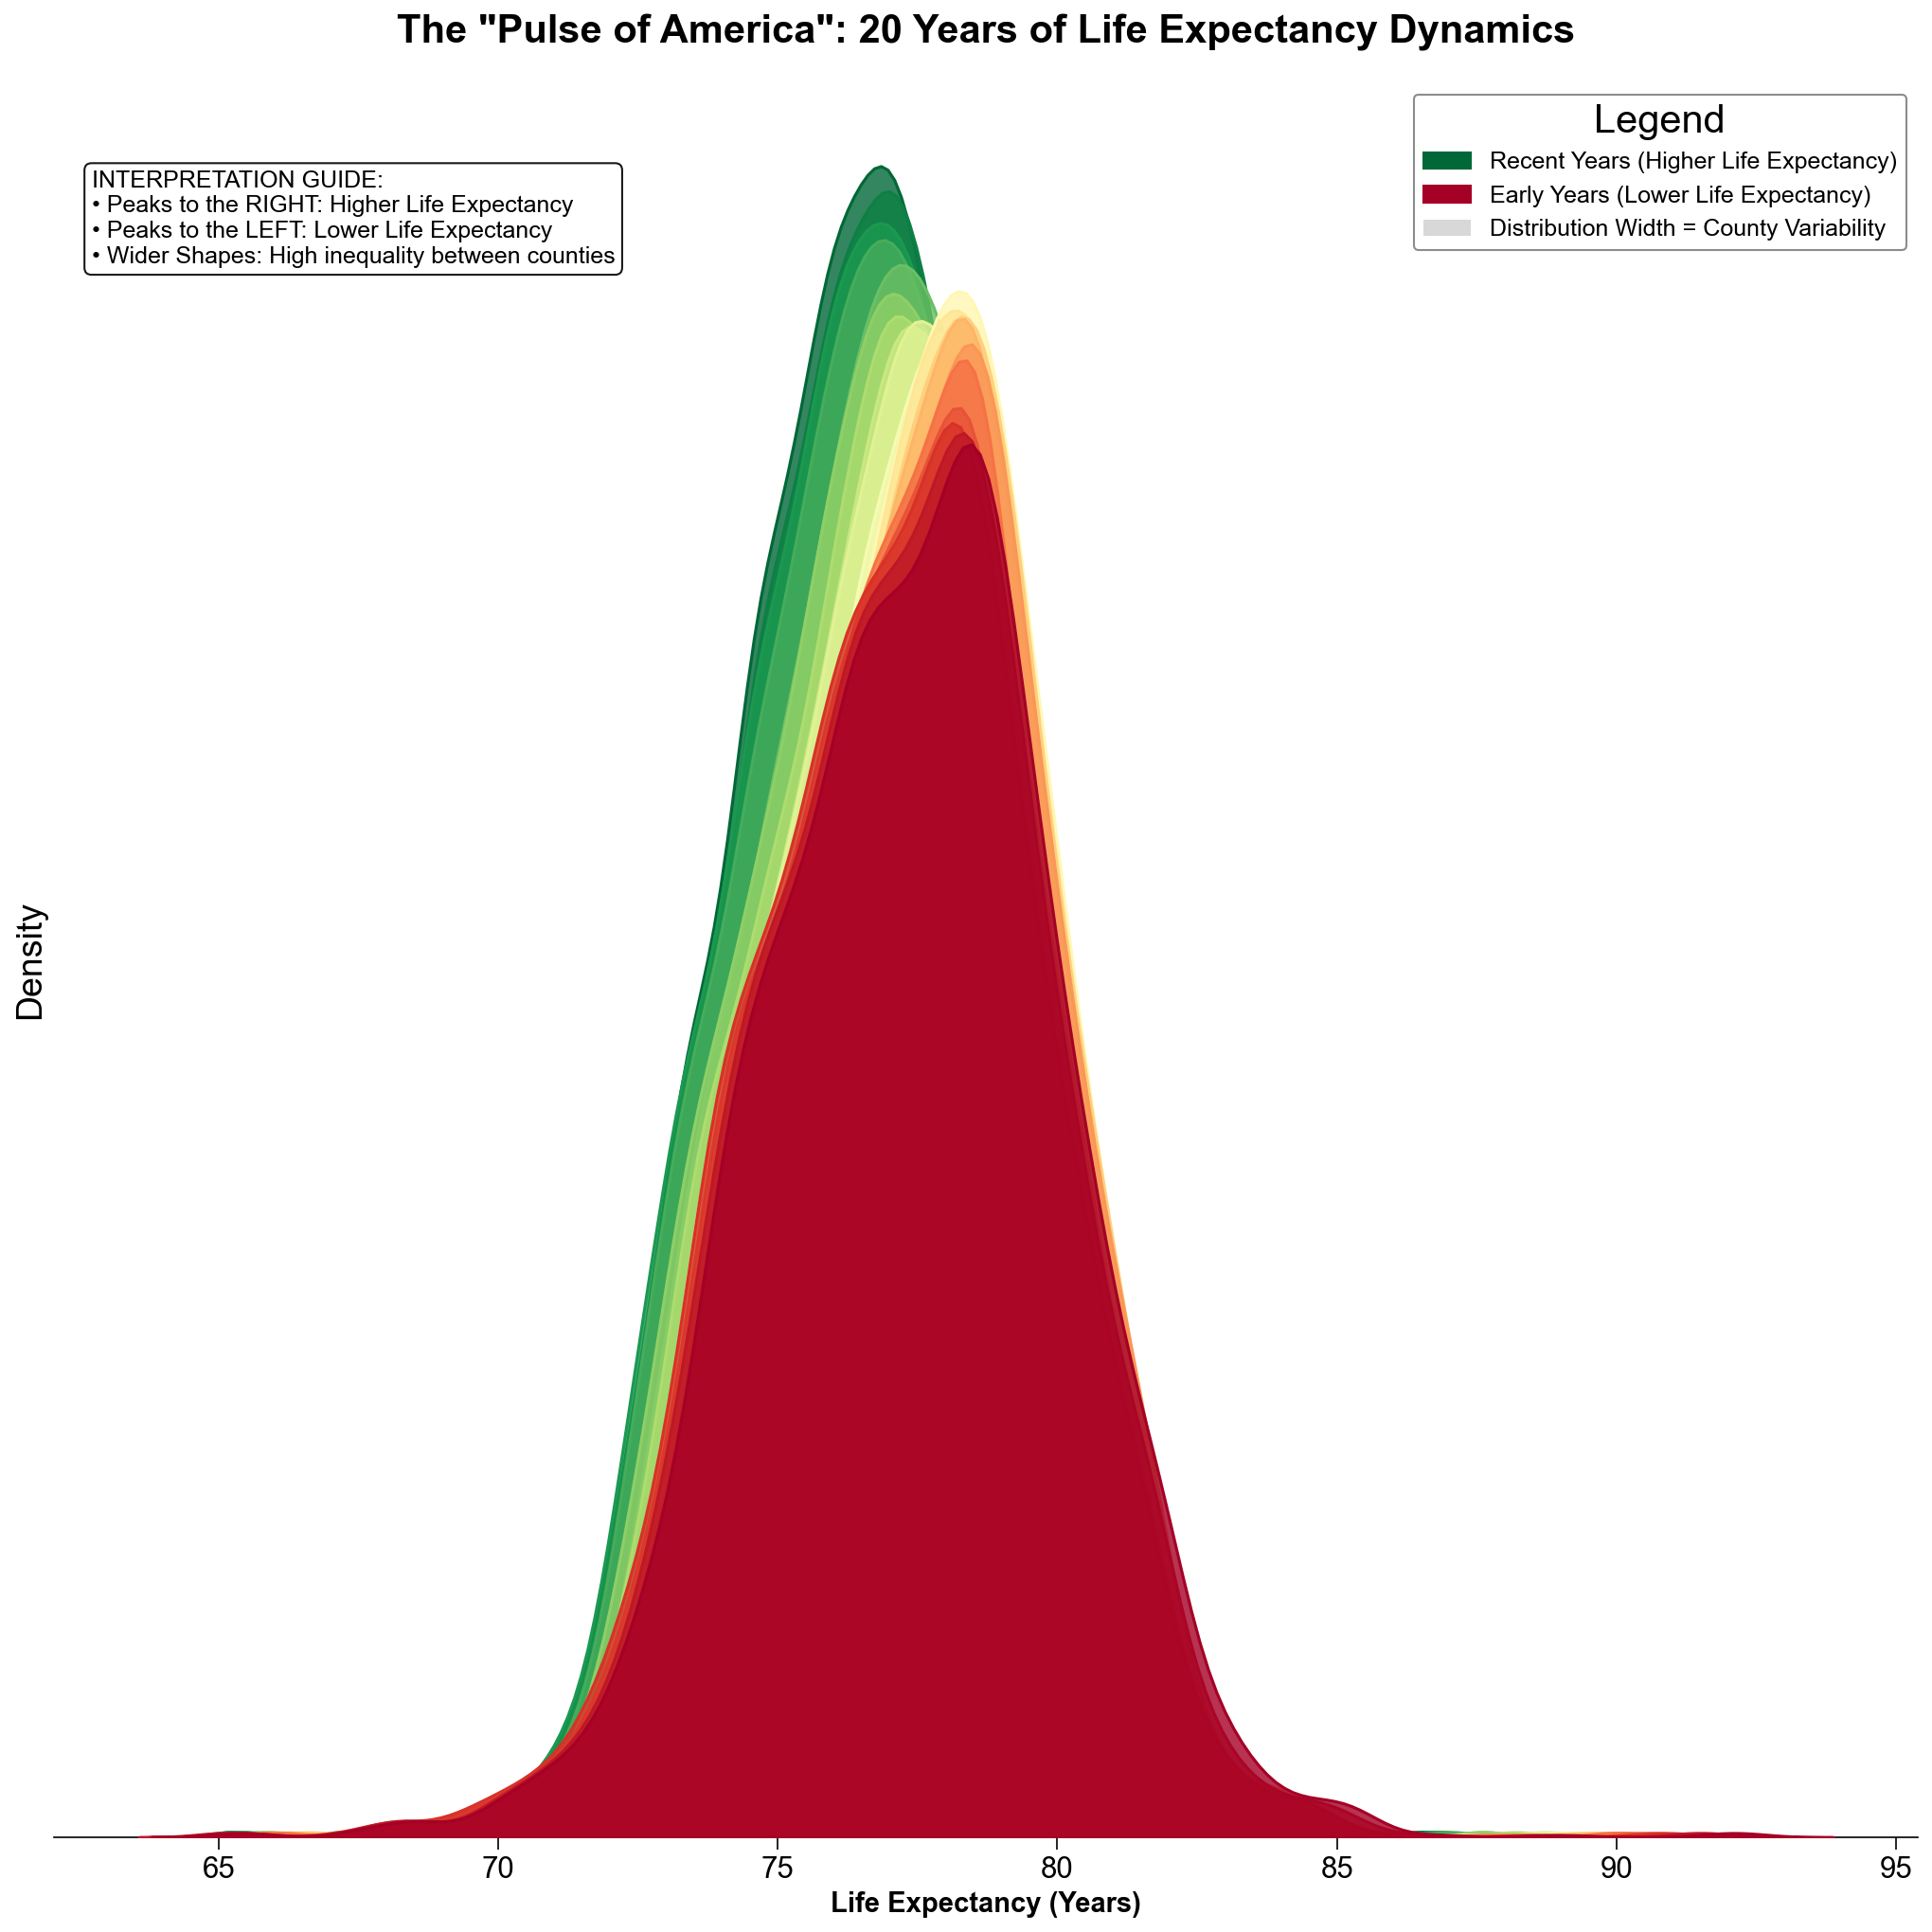

In [46]:
# Figure A starts here
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║   Phase 2.5: Robust EDA - Visual A: Life Expectancy Ridgeline           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# Ensure directory exists
PLOT_DIR = '/Users/faizahmad/Desktop/multimodal/sanity_check/plots'
os.makedirs(PLOT_DIR, exist_ok=True)


def plot_le_ridgeline_enhanced(error_master_df):
    print("\n🎨 Generating Visual A (Enhanced)...")

    # 1. Data Prep - Use actual and predicted life expectancy
    plot_df = error_master_df[['year', 'actual']].copy()
    plot_df['actual'] = pd.to_numeric(plot_df['actual'], errors='coerce')
    plot_df = plot_df.dropna()
    plot_df = plot_df[(plot_df['year'] >= 2000) & (plot_df['year'] <= 2019)]

    if plot_df.empty:
        print("   ❌ ERROR: Plot DataFrame is empty after filtering.")
        return

    # 2. Plotting
    years = sorted(plot_df['year'].unique(), reverse=True)
    colors = plt.cm.RdYlGn(np.linspace(0, 1, len(years)))

    fig, ax = plt.subplots(figsize=(14, 14))

    legend_elements = [
        mpatches.Patch(color=colors[-1], label='Recent Years (Higher Life Expectancy)'),
        mpatches.Patch(color=colors[0], label='Early Years (Lower Life Expectancy)'),
        mpatches.Patch(facecolor='grey', alpha=0.3, label='Distribution Width = County Variability')
    ]

    lines_plotted = 0
    for i, year in enumerate(years):
        subset = plot_df[plot_df['year'] == year]['actual']
        if len(subset) < 10 or subset.nunique() < 2: 
            continue

        y_base = i * 0.35

        try:
            sns.kdeplot(data=subset, ax=ax, fill=True, alpha=0.8,
                        linewidth=1.5, color=colors[i], zorder=len(years)-i)

            if len(ax.lines) > lines_plotted:
                line = ax.lines[-1]
                poly = ax.collections[-1]
                line.set_ydata(line.get_ydata() + y_base)
                paths = poly.get_paths()[0]
                paths.vertices[:, 1] += y_base

                ax.text(subset.min(), y_base + 0.05, str(year),
                        fontweight='bold', fontsize=12, ha='right', color='#333333')
                lines_plotted += 1
        except: 
            continue

    ax.set_yticks([])
    ax.set_xlabel('Life Expectancy (Years)', fontweight='bold', fontsize=14)
    ax.set_title('The "Pulse of America": 20 Years of Life Expectancy Dynamics',
                 pad=20, fontweight='bold', fontsize=20)

    stats_text = (
        "INTERPRETATION GUIDE:\n"
        "• Peaks to the RIGHT: Higher Life Expectancy\n"
        "• Peaks to the LEFT: Lower Life Expectancy\n"
        "• Wider Shapes: High inequality between counties"
    )
    ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    ax.legend(handles=legend_elements, loc='upper right', fontsize=12, title="Legend")
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, 'Visual_A_Enhanced.png'), dpi=300, bbox_inches='tight')
    print("   ✅ Visual A Saved.")
    plt.show()

# --- EXECUTE FIGURE A ---
plot_le_ridgeline_enhanced(error_master_df)


Plots will be saved to:  /Users/faizahmad/Desktop/LE Crop data/plots_ag_le_2025


Generating:  A – NDVI Ridgeline (temporal vegetation health)
   Using column: Landsat_NDVI_mean
   Year 2019 skipped – error: list index out of range
   Year 2018 skipped – error: list index out of range
   Year 2017 skipped – error: list index out of range
   Year 2016 skipped – error: list index out of range
   Year 2015 skipped – error: list index out of range
   Year 2014 skipped – error: list index out of range
   Year 2013 skipped – error: list index out of range
   Saved → A_NDVI_Ridgeline_Enhanced.png


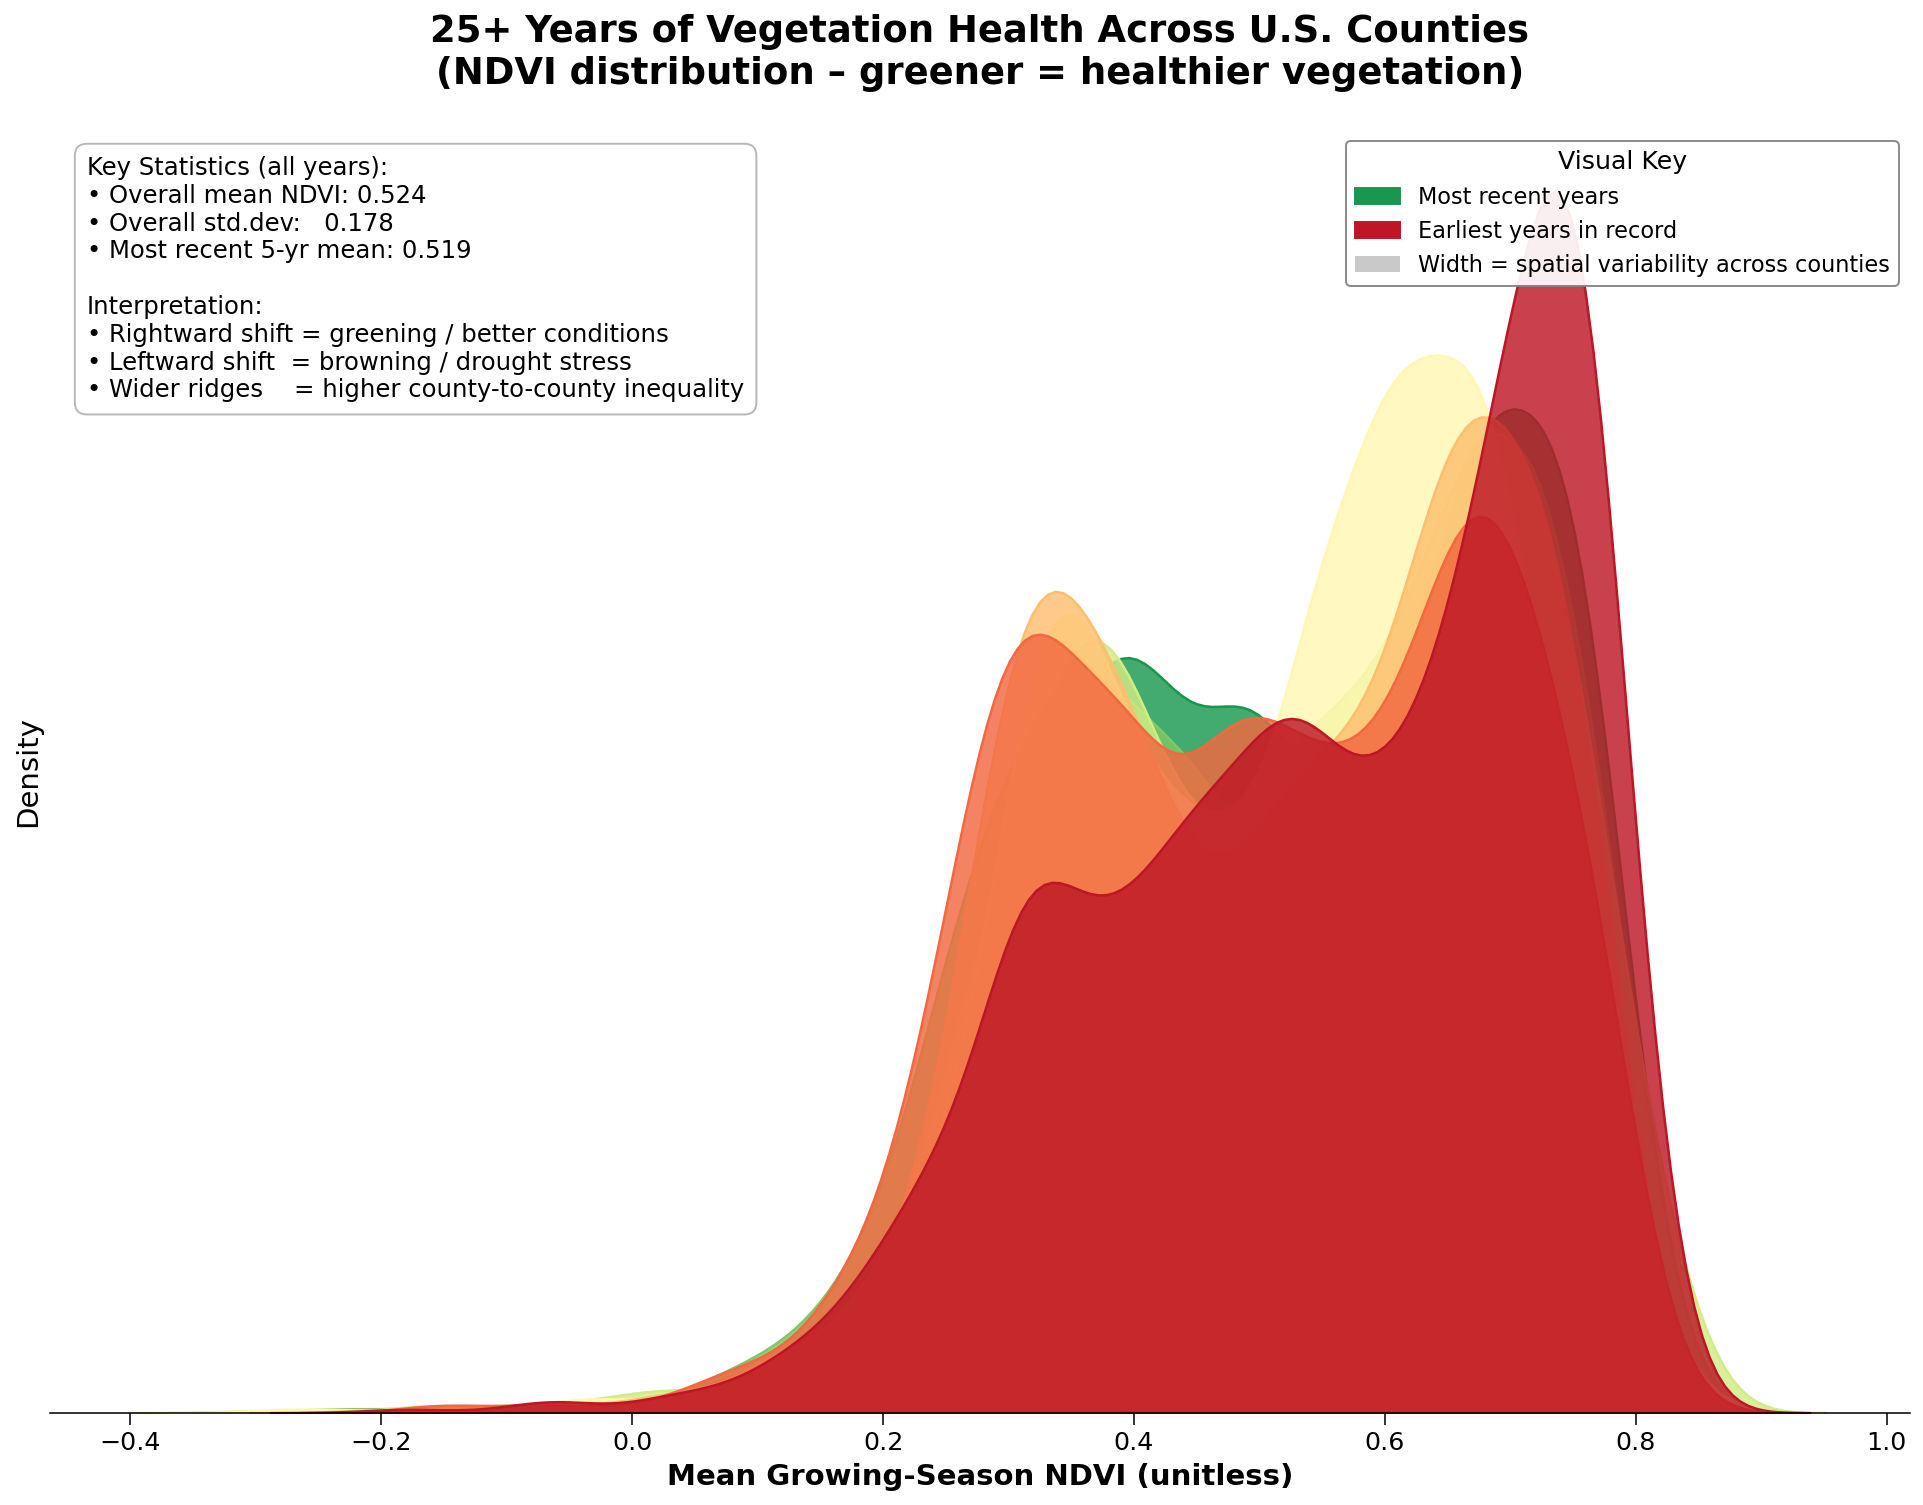


Generating:  B – Landscape / Crop Composition Evolution
   Found 133 crop/landcover columns
   Saved → B_Landscape_Composition_Enhanced.png


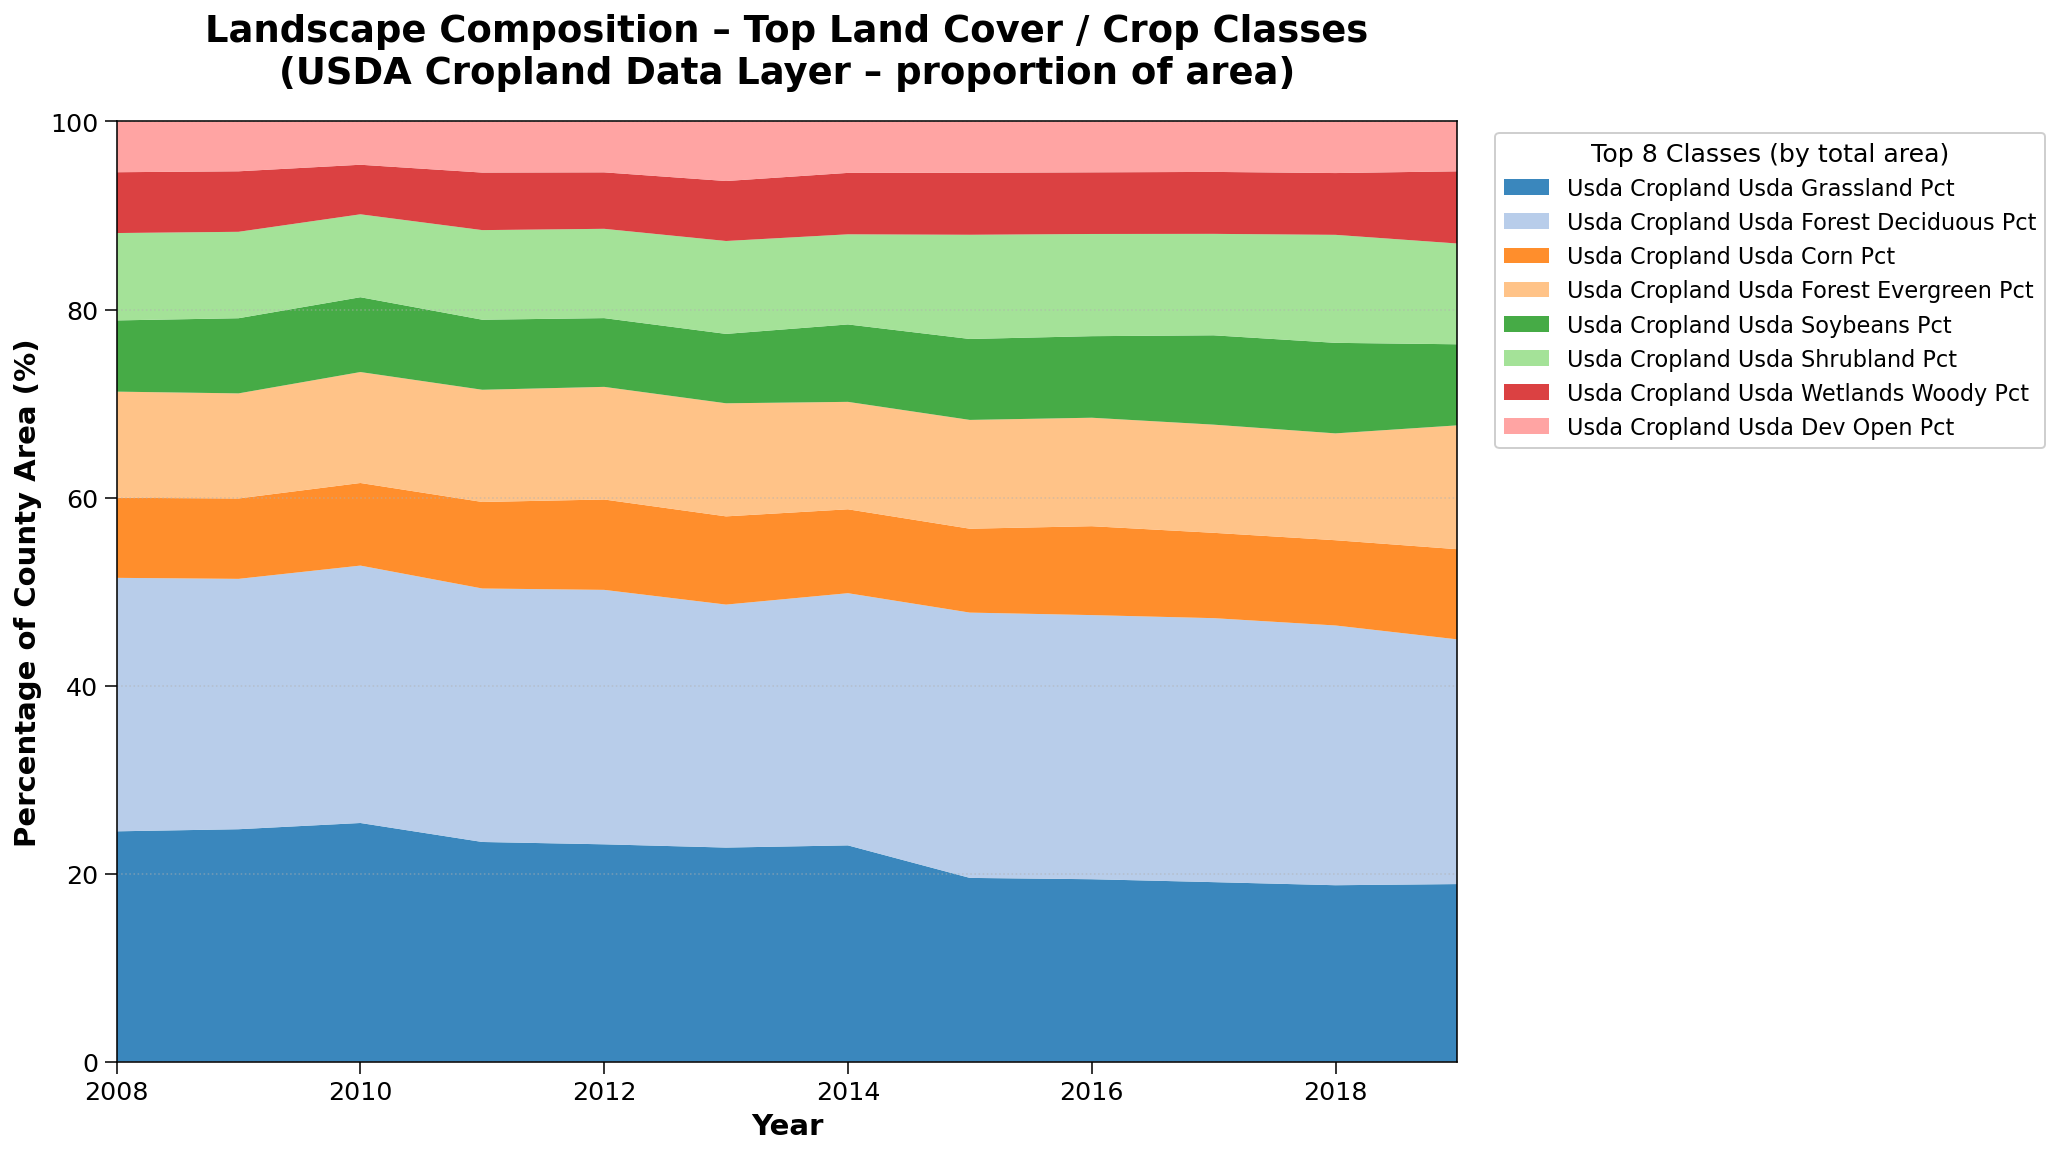

In [127]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║   Phase 2.6: ENHANCED VISUALIZATION – Local VS Code / Jupyter friendly    ║
# ╚════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
import os
from pathlib import Path

# ────  CONFIGURATION ────────────────────────────────────────────────
# Change this to wherever you want plots saved
PLOT_DIR = Path("plots_ag_le_2025").resolve()           # relative to script
# PLOT_DIR = Path("/Users/yourname/research/plots")     # absolute path example

PLOT_DIR.mkdir(exist_ok=True, parents=True)
print(f"Plots will be saved to:  {PLOT_DIR}\n")

# ──── USDA Cropland Data Layer class names ──────────────────────────
USDA_CROP_MAP = {
    1:   'Corn',
    5:   'Soybeans',
    24:  'Winter Wheat',
    4:   'Sorghum',
    23:  'Spring Wheat',
    36:  'Alfalfa',
    2:   'Cotton',
    176: 'Grass/Pasture',
    152: 'Shrubland',
    141: 'Deciduous Forest',
    142: 'Evergreen Forest',
    121: 'Developed/Open Space',
    122: 'Developed/Low Intensity',
    123: 'Developed/Medium Intensity',
    124: 'Developed/High Intensity',
    111: 'Open Water',
    190: 'Woody Wetlands',
    195: 'Herbaceous Wetlands',
    # Add more codes if your dataset contains them
}

def get_crop_name(col_name: str) -> str:
    """Convert column like 'cropland_usda_1_pct' → 'Corn'"""
    try:
        code_str = col_name.split('_')[-1]
        if code_str.endswith('_pct') or code_str.endswith('_percent'):
            code_str = code_str.rsplit('_', 1)[0]
        code = int(code_str)
        return USDA_CROP_MAP.get(code, f"Class {code}")
    except:
        return col_name.replace('_', ' ').title()


# ──── A. Enhanced NDVI Ridgeline Plot ───────────────────────────────
def plot_ndvi_ridgeline_enhanced(df: pd.DataFrame, save: bool = True):
    print("\nGenerating:  A – NDVI Ridgeline (temporal vegetation health)")

    ndvi_cols = [c for c in df.columns if 'NDVI' in c.upper() and 'mean' in c.lower()]
    if not ndvi_cols:
        print("   ⚠️  No NDVI mean columns found. Skipping.")
        return

    ndvi_col = next((c for c in ndvi_cols if 'modis' in c.lower()), ndvi_cols[0])
    print(f"   Using column: {ndvi_col}")

    # Prepare data
    plot_df = df[['year', ndvi_col]].copy()
    plot_df[ndvi_col] = pd.to_numeric(plot_df[ndvi_col], errors='coerce')
    plot_df = plot_df.dropna(subset=[ndvi_col, 'year'])

    if plot_df.empty:
        print("   No valid NDVI data after cleaning → skipping")
        return

    years = sorted(plot_df['year'].unique(), reverse=True)
    years = [y for y in years if 2000 <= y <= 2019]  # sensible default range

    if len(years) < 3:
        print(f"   Only {len(years)} years available — ridgeline may look sparse")

    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.95, len(years)))  # reversed = newer greener

    fig, ax = plt.subplots(figsize=(14, 11))

    legend_elements = [
        mpatches.Patch(color=colors[0],  label='Most recent years'),
        mpatches.Patch(color=colors[-1], label='Earliest years in record'),
        mpatches.Patch(facecolor='0.4', alpha=0.35, label='Width = spatial variability across counties'),
    ]

    n_plotted = 0
    for i, year in enumerate(years):
        subset = plot_df[plot_df['year'] == year][ndvi_col]
        if len(subset) < 15 or subset.std() < 1e-4:
            continue

        y_base = n_plotted * 0.42

        try:
            sns.kdeplot(
                x=subset,
                ax=ax,
                fill=True,
                alpha=0.82,
                linewidth=1.3,
                color=colors[i],
                bw_adjust=0.9
            )

            # Shift the kde curve & fill
            line = ax.lines[-1]
            poly = ax.collections[-1]

            line.set_ydata(line.get_ydata() + y_base)
            for path in poly.get_paths():
                path.vertices[:, 1] += y_base

            # Year label
            mean_val = subset.mean()
            ax.text(mean_val, y_base + 0.12, str(int(year)),
                    fontsize=13, fontweight='bold', ha='center', va='bottom',
                    color='0.1', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.8))

            n_plotted += 1

        except Exception as e:
            print(f"   Year {year} skipped – error: {e}")

    # ─── Styling & annotation ─────────────────────────────────────
    ax.set_yticks([])
    ax.set_xlabel('Mean Growing-Season NDVI (unitless)', fontsize=15, fontweight='600')
    ax.set_title('25+ Years of Vegetation Health Across U.S. Counties\n'
                 '(NDVI distribution – greener = healthier vegetation)',
                 fontsize=19, fontweight='bold', pad=24)

    # Statistics & interpretation box
    overall_mean = plot_df[ndvi_col].mean()
    overall_std  = plot_df[ndvi_col].std()
    recent_mean  = plot_df[plot_df['year'] >= plot_df['year'].max()-5][ndvi_col].mean()

    stats_text = (
        f"Key Statistics (all years):\n"
        f"• Overall mean NDVI: {overall_mean:.3f}\n"
        f"• Overall std.dev:   {overall_std:.3f}\n"
        f"• Most recent 5-yr mean: {recent_mean:.3f}\n\n"
        "Interpretation:\n"
        "• Rightward shift = greening / better conditions\n"
        "• Leftward shift  = browning / drought stress\n"
        "• Wider ridges    = higher county-to-county inequality"
    )

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=12.5, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='0.7', alpha=0.94))

    ax.legend(handles=legend_elements,
              loc='upper right',
              fontsize=11.5,
              title='Visual Key',
              title_fontsize=13,
              framealpha=0.92)

    for spine in ['top','right','left']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    if save:
        save_path = PLOT_DIR / "A_NDVI_Ridgeline_Enhanced.png"
        plt.savefig(save_path, dpi=360, bbox_inches='tight')
        print(f"   Saved → {save_path.name}")
    plt.show()
    plt.close(fig)


# ──── B. Enhanced Landscape Composition Stack Area ──────────────────
def plot_land_evolution_enhanced(df: pd.DataFrame, save: bool = True, top_n: int = 8):
    print("\nGenerating:  B – Landscape / Crop Composition Evolution")

    crop_cols = [c for c in df.columns if 'cropland_usda' in c.lower() or 'cdl' in c.lower()]
    if not crop_cols:
        print("   No USDA Cropland / CDL columns found → skipping")
        return

    print(f"   Found {len(crop_cols)} crop/landcover columns")

    temp_df = df[['year'] + crop_cols].copy()
    for col in crop_cols:
        temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce').fillna(0)

    # Get top N most abundant classes overall
    total_per_class = temp_df[crop_cols].sum()
    top_cols = total_per_class.nlargest(top_n).index.tolist()

    labels = [get_crop_name(c) for c in top_cols]

    # Group by year and normalize
    yearly = temp_df.groupby('year')[top_cols].sum()
    yearly_prop = yearly.div(yearly.sum(axis=1), axis=0) * 100   # in percent

    # Filter sensible years
    yearly_prop = yearly_prop.loc[yearly_prop.index >= 2008]   # CDL starts ~2008

    if yearly_prop.empty:
        print("   No data after year filtering → skipping")
        return

    fig, ax = plt.subplots(figsize=(15, 8.5))

    ax.stackplot(yearly_prop.index.astype(int),
                 yearly_prop.T,
                 labels=labels,
                 colors=plt.cm.tab20.colors[:len(top_cols)],
                 alpha=0.88,
                 baseline='zero')

    ax.set_title('Landscape Composition – Top Land Cover / Crop Classes\n'
                 '(USDA Cropland Data Layer – proportion of area)',
                 fontsize=19, fontweight='bold', pad=20)

    ax.set_ylabel('Percentage of County Area (%)', fontsize=15, fontweight='600')
    ax.set_xlabel('Year', fontsize=15, fontweight='600')
    ax.set_xlim(yearly_prop.index.min(), yearly_prop.index.max())
    ax.set_ylim(0, 100)

    ax.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left',
              title=f"Top {len(top_cols)} Classes (by total area)",
              fontsize=11.5, title_fontsize=13,
              framealpha=0.95, edgecolor='0.8')

    ax.grid(True, axis='y', linestyle=':', alpha=0.5)

    plt.tight_layout()
    if save:
        save_path = PLOT_DIR / "B_Landscape_Composition_Enhanced.png"
        plt.savefig(save_path, dpi=360, bbox_inches='tight')
        print(f"   Saved → {save_path.name}")
    plt.show()
    plt.close(fig)


# ──── RUN ───────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Replace this with your actual data loading logic
    # Example placeholder:
    # df = pd.read_csv("/Users/faizahmad/Desktop/multimodal/master csv/ROBUST_ML_DATASET_v1_first_run.csv", low_memory=False)
    # For testing you can use:
    # df = pd.DataFrame(...)  # or load your real data here

    try:
        # Assuming df is already loaded in your notebook/script
        plot_ndvi_ridgeline_enhanced(df)
        plot_land_evolution_enhanced(df, top_n=8)
    except NameError:
        print("\nERROR: variable 'df' not found.")
        print("Please load your DataFrame before calling the plotting functions.\n")


🎨 Generating Visual B (Enhanced)...
   -> Found 132 land-cover columns.
   -> Top Classes:
       Grassland/Pasture %
       Deciduous Forest %
       Corn %
       Evergreen Forest %
       Soybeans %
       Shrubland %
       Woody Wetlands %
✅ Saved: /Users/faizahmad/Desktop/multimodal/sanity_check/plots/Visual_B_Enhanced.png


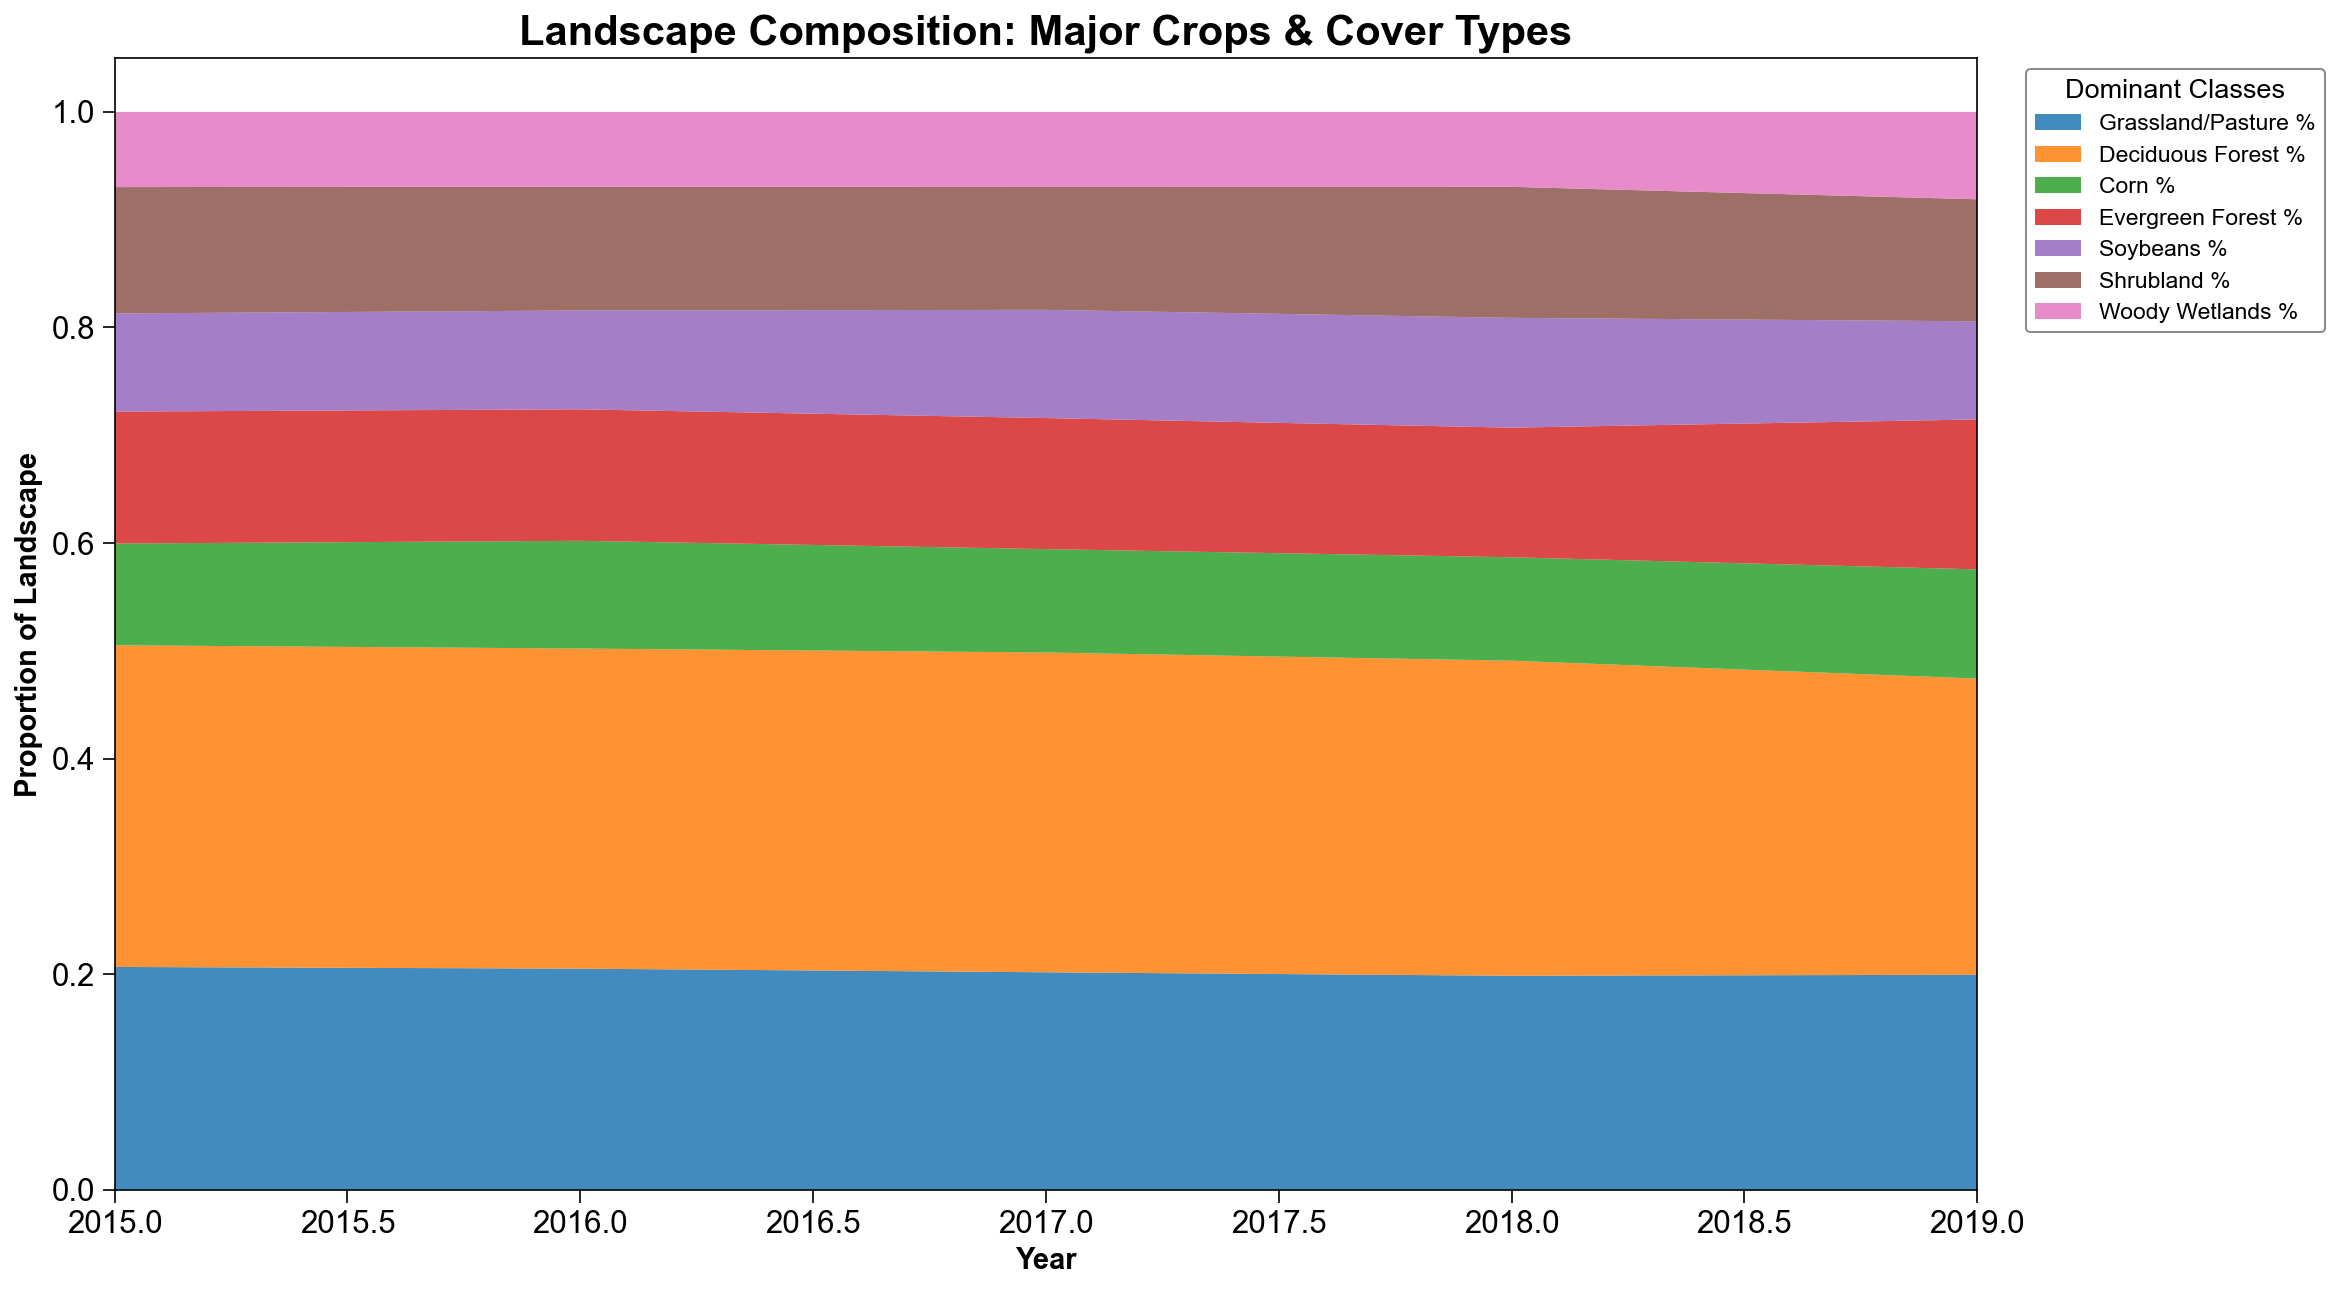

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import re

# Ensure directory exists
PLOT_DIR = '/Users/faizahmad/Desktop/multimodal/sanity_check/plots'
os.makedirs(PLOT_DIR, exist_ok=True)


def plot_land_evolution_enhanced(df):

    print("\n🎨 Generating Visual B (Enhanced)...")

    # ---------------------------------------------------
    # 1. Find percentage-based land cover columns
    #    (Ends with " %", but excludes water & metadata)
    # ---------------------------------------------------

    percent_cols = [
        c for c in df.columns
        if re.search(r'\s%$', c) and
        not re.search(r'Water|Density|Growth|Std|Error|Variance|Temp|Moisture|NDVI|Life|Area', c)
    ]

    if not percent_cols:
        print("❌ No land-cover % columns found.")
        return

    print(f"   -> Found {len(percent_cols)} land-cover columns.")


    # ---------------------------------------------------
    # 2. Prepare dataframe
    # ---------------------------------------------------

    temp_df = df[['year'] + percent_cols].copy()

    # Force numeric
    for col in percent_cols:
        temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')

    temp_df = temp_df.fillna(0)


    # ---------------------------------------------------
    # 3. Find Top 7 dominant classes
    # ---------------------------------------------------

    yearly_sums = temp_df.groupby('year')[percent_cols].mean()

    if yearly_sums.empty:
        print("❌ Aggregation failed.")
        return

    top_cols = (
        yearly_sums
        .mean()
        .nlargest(7)
        .index
        .tolist()
    )

    print("   -> Top Classes:")
    for c in top_cols:
        print("      ", c)


    # ---------------------------------------------------
    # 4. Build plot matrix
    # ---------------------------------------------------

    plot_data = temp_df.groupby('year')[top_cols].mean()

    # Normalize to proportions
    plot_data = plot_data.div(plot_data.sum(axis=1), axis=0)


    # Filter recent years
    plot_data = plot_data[plot_data.index >= 2015]

    if plot_data.empty:
        print("❌ No data after year filtering.")
        return


    # ---------------------------------------------------
    # 5. Plot
    # ---------------------------------------------------

    fig, ax = plt.subplots(figsize=(16, 9))

    ax.stackplot(
        plot_data.index,
        plot_data.T,
        labels=top_cols,
        alpha=0.85
    )

    ax.set_title(
        'Landscape Composition: Major Crops & Cover Types',
        fontsize=20,
        fontweight='bold'
    )

    ax.set_ylabel('Proportion of Landscape', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=14, fontweight='bold')

    ax.set_xlim(plot_data.index.min(), plot_data.index.max())

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        title='Dominant Classes',
        fontsize=11,
        title_fontsize=13
    )

    plt.tight_layout()

    save_path = os.path.join(PLOT_DIR, 'Visual_B_Enhanced.png')
    plt.savefig(save_path, dpi=200)

    print(f"✅ Saved: {save_path}")

    plt.show()


# ---------------------------------------------------
# Run
# ---------------------------------------------------

plot_land_evolution_enhanced(df)


In [ ]:
%who
df.head().to_dict('records')

In [ ]:
from pathlib import Path
import geopandas as gpd

# Define Paths
COUNTY_SHP = Path("/Users/faizahmad/Desktop/grok_live/data/cb_2018_us_county_500k/cb_2018_us_county_500k.shp")
STATE_SHP = Path("/Users/faizahmad/Desktop/grok_live/data/cb_2018_us_state_500k/cb_2018_us_state_500k.shp")

# Load shapefiles
print("Loading County Shapefile...")
counties = gpd.read_file(COUNTY_SHP)
print(f"Counties shape: {counties.shape}")
print("\nCounties columns:")
print(counties.head())

print("\n" + "="*80 + "\n")

print("Loading State Shapefile...")
states = gpd.read_file(STATE_SHP)
print(f"States shape: {states.shape}")
print("\nStates columns:")
print(states.head())

Loading spatial and temporal data...

Searching for NDVI columns...
✅ Using: NDVI_EVI_mean
Data shape: (61540, 3)
Year range: 2000 to 2019

🎨 Generating NDVI Visualizations...



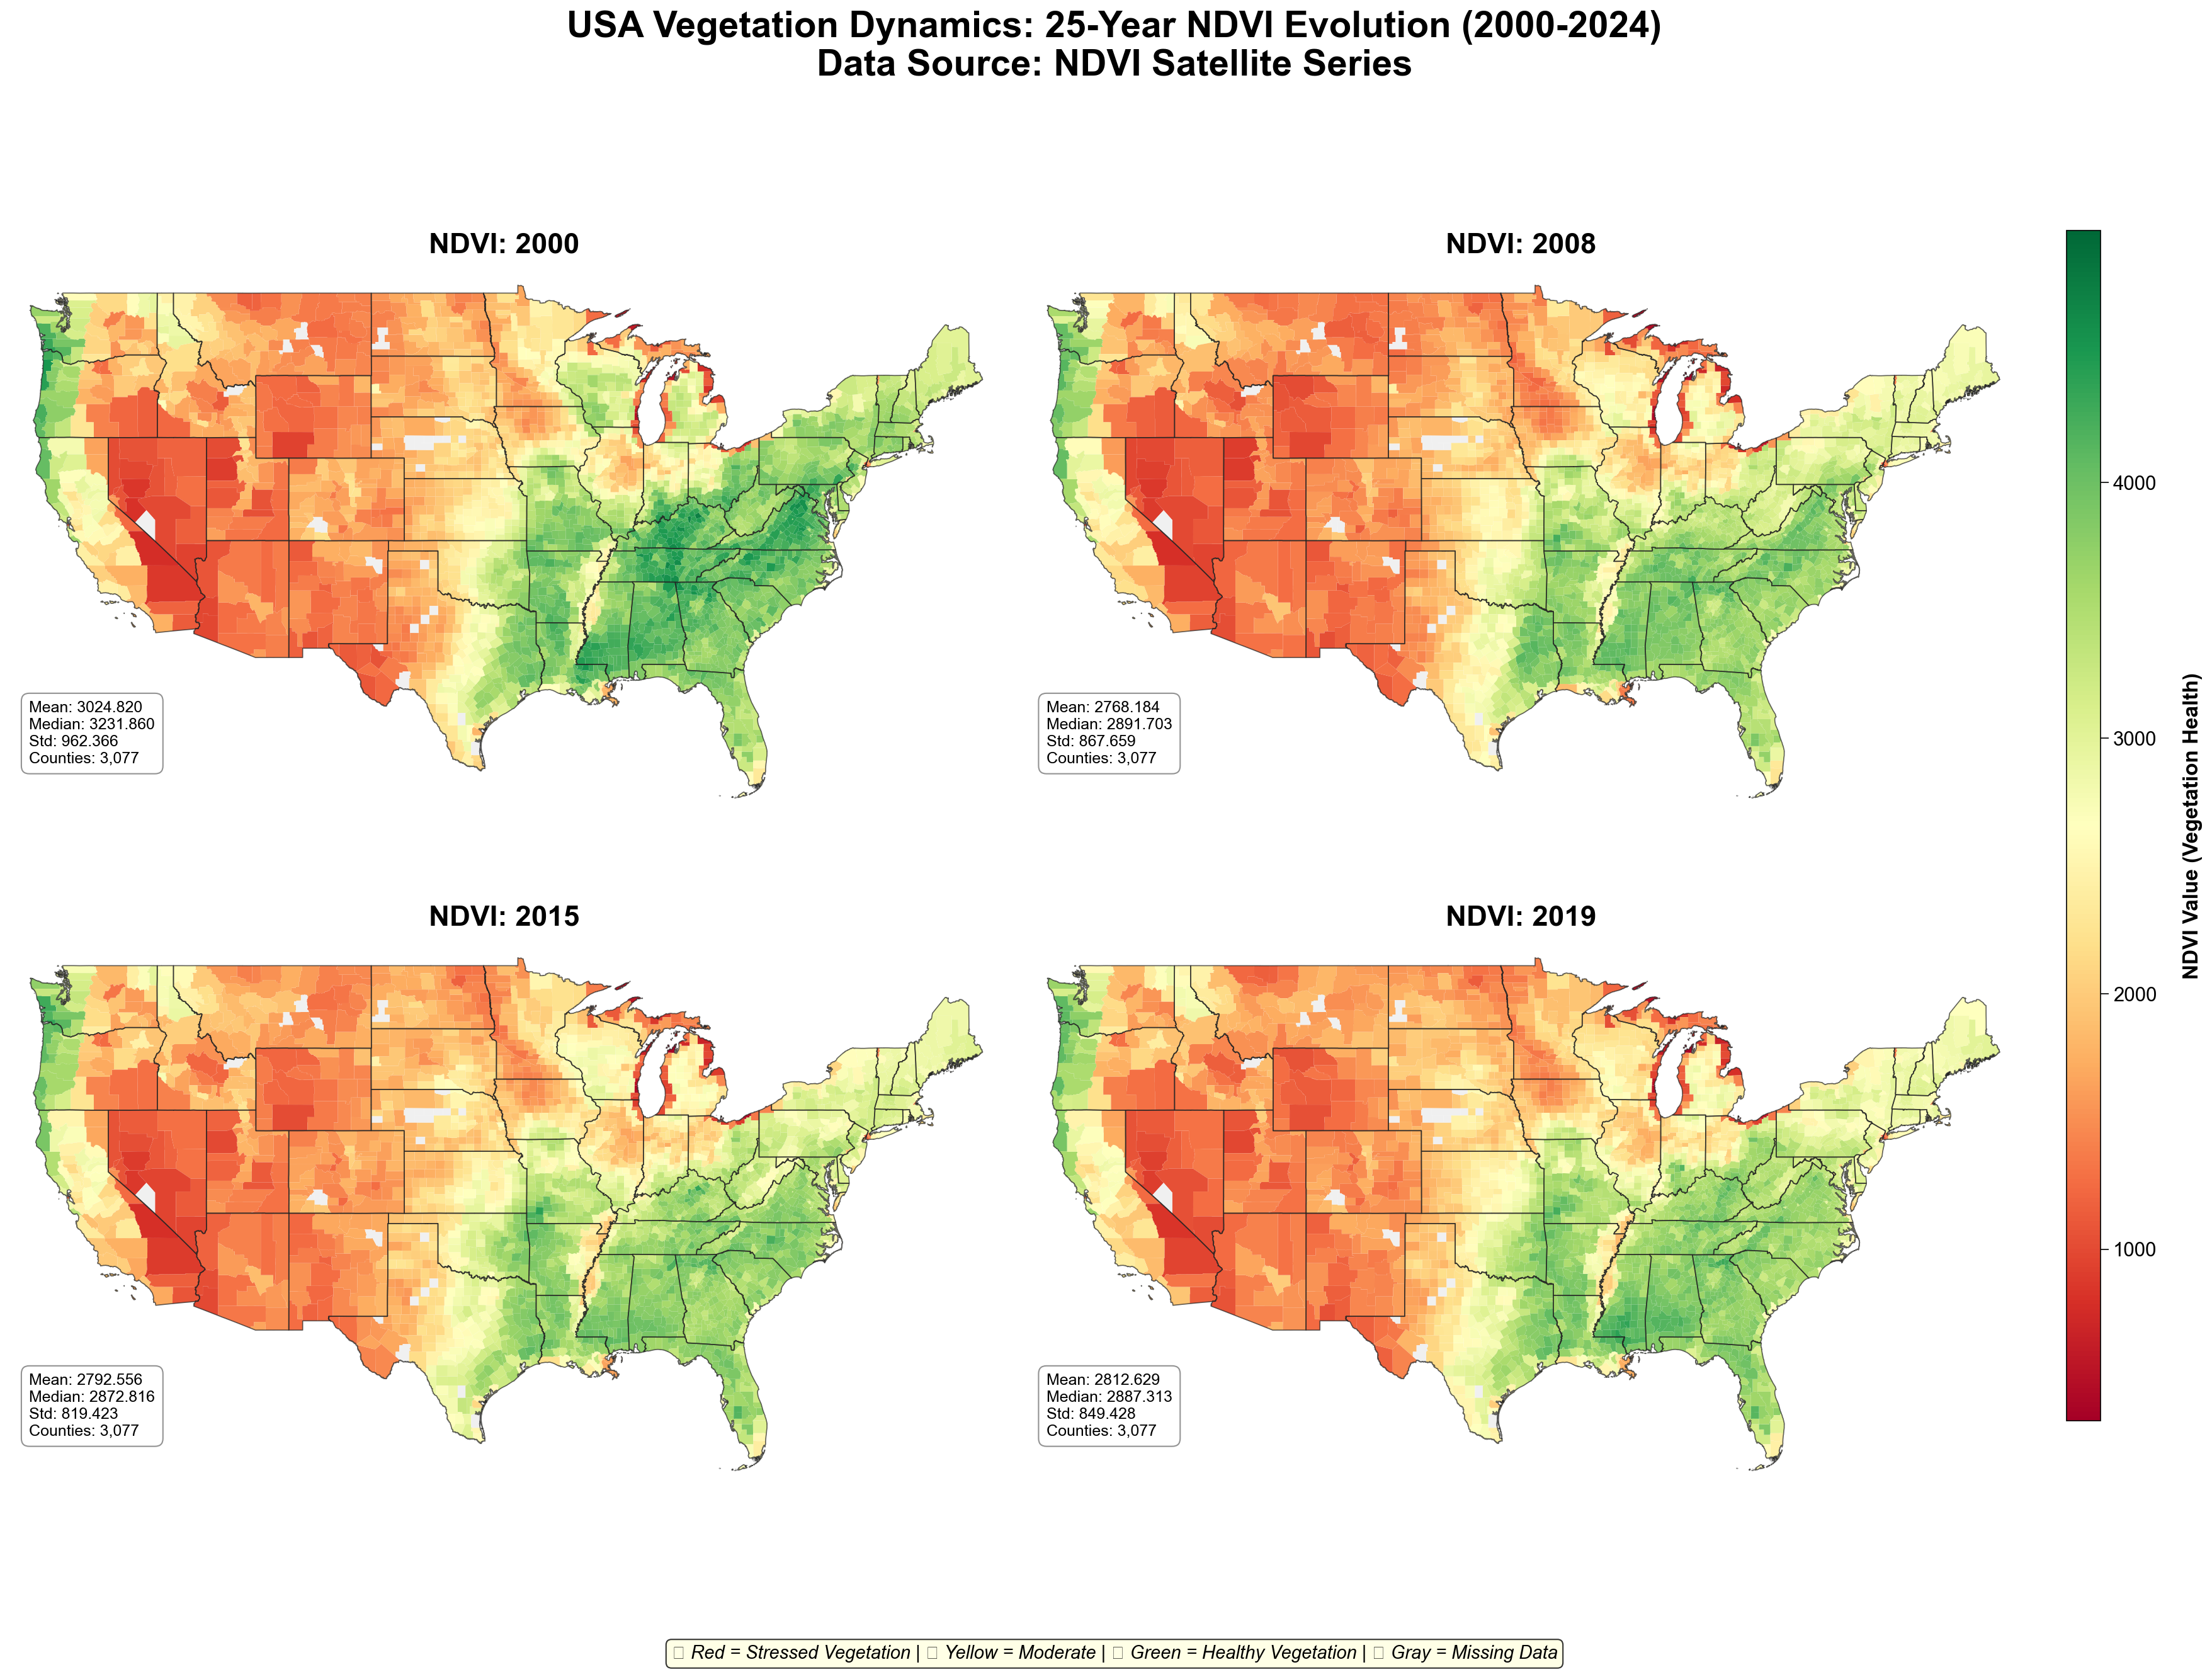

✅ Saved: NDVI_Timeline_4Panel_Vibrant.png



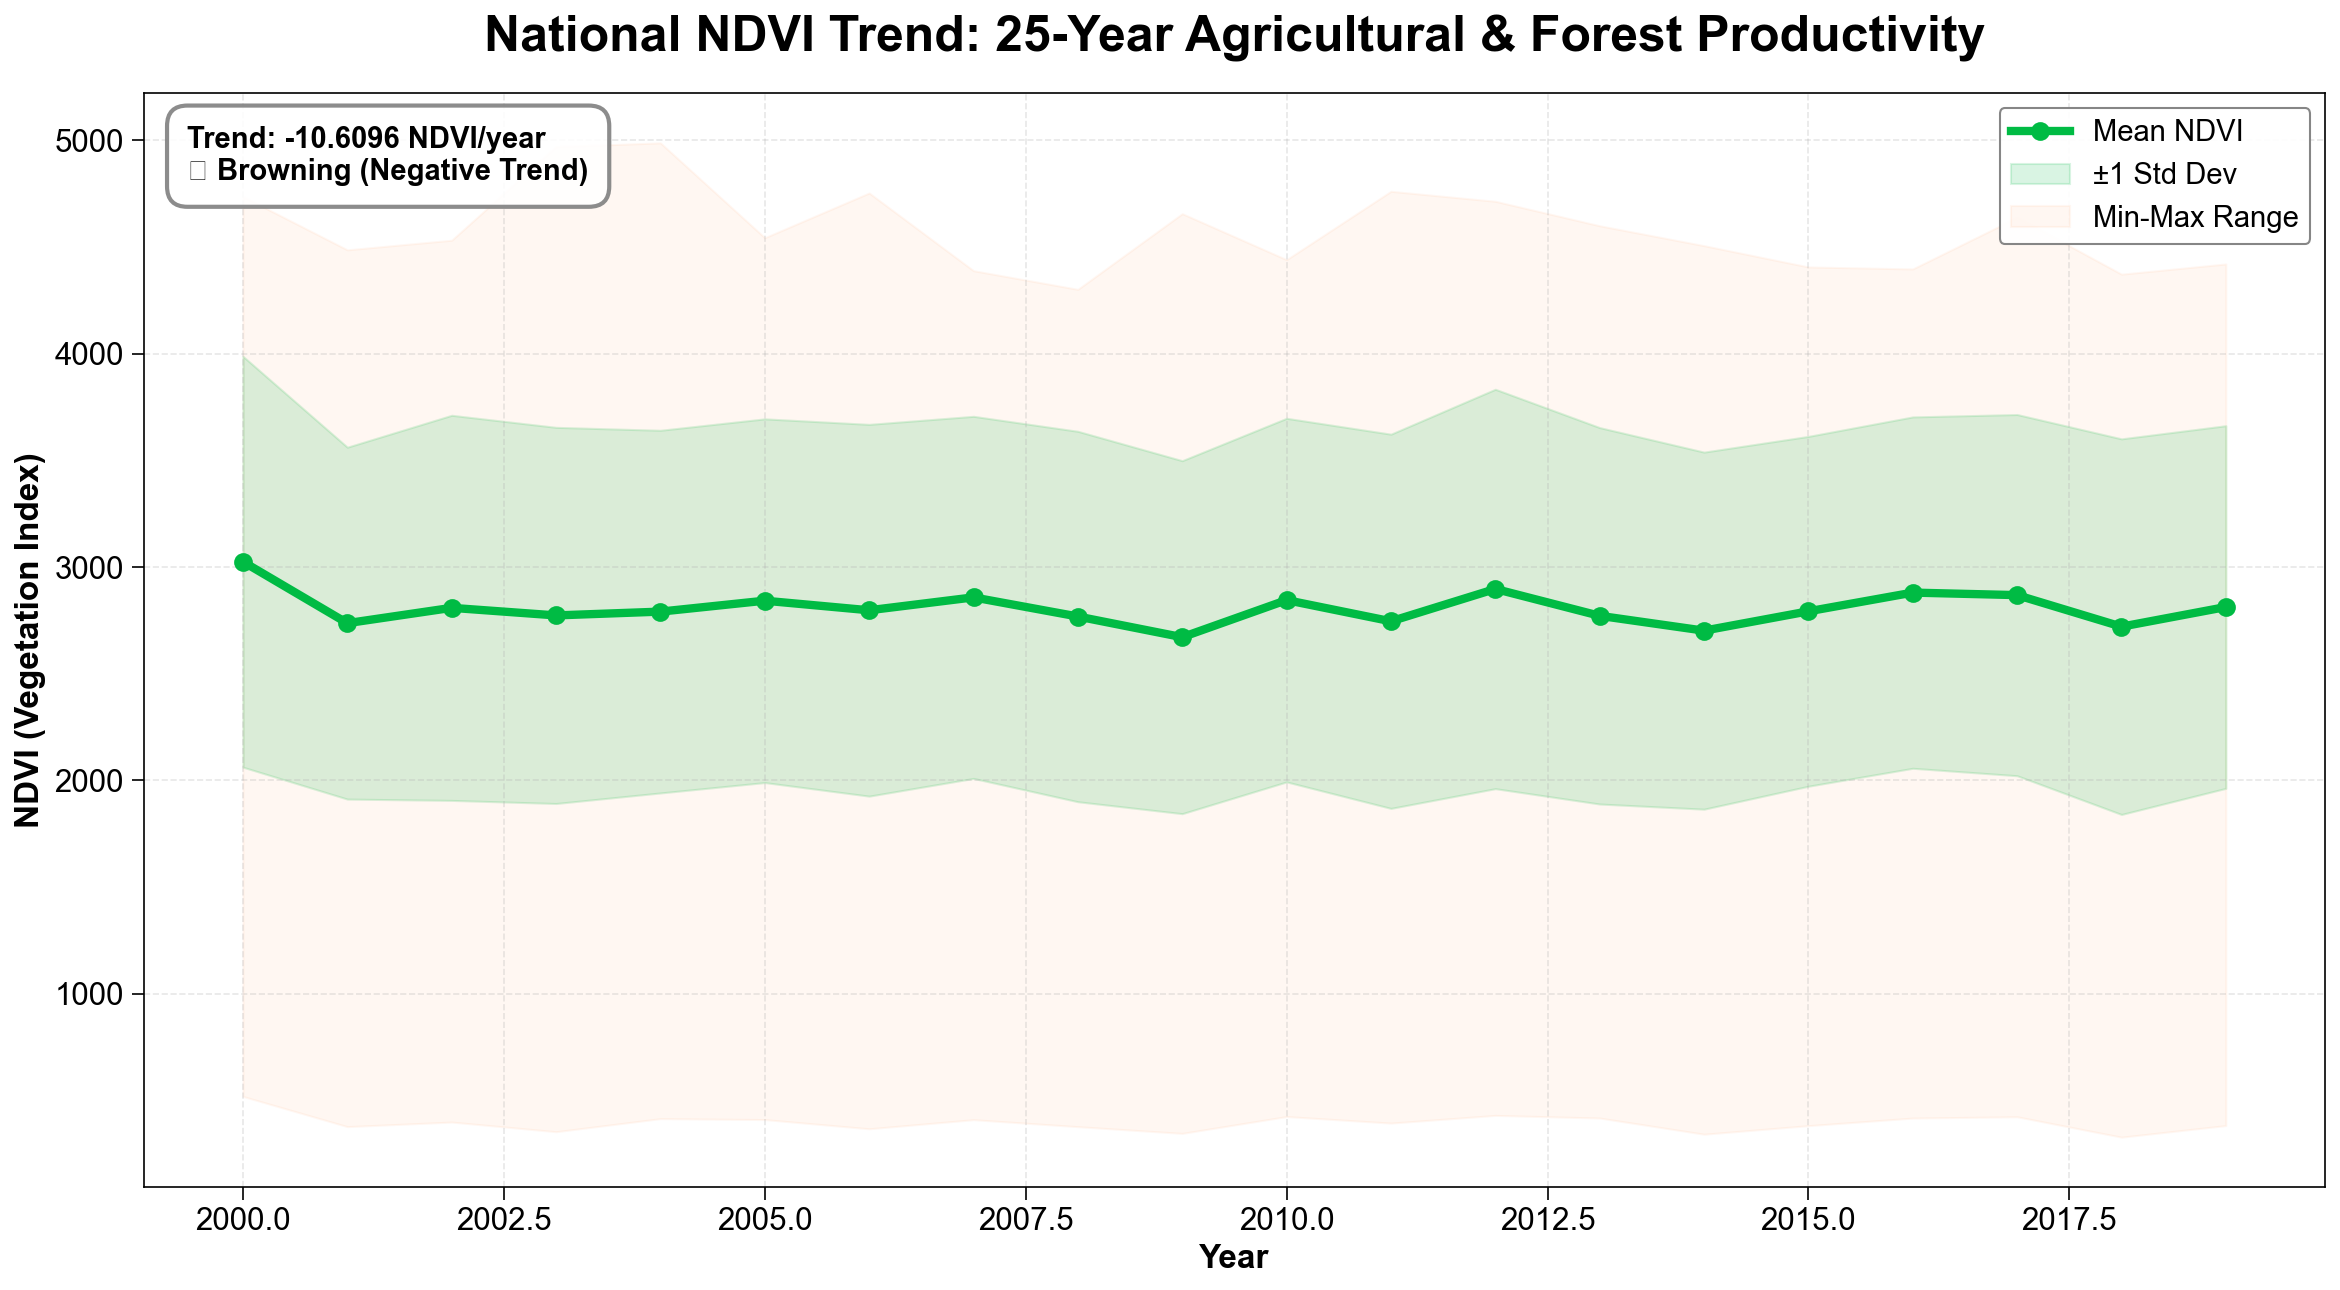

✅ Saved: NDVI_National_Trend_TimeSeries.png



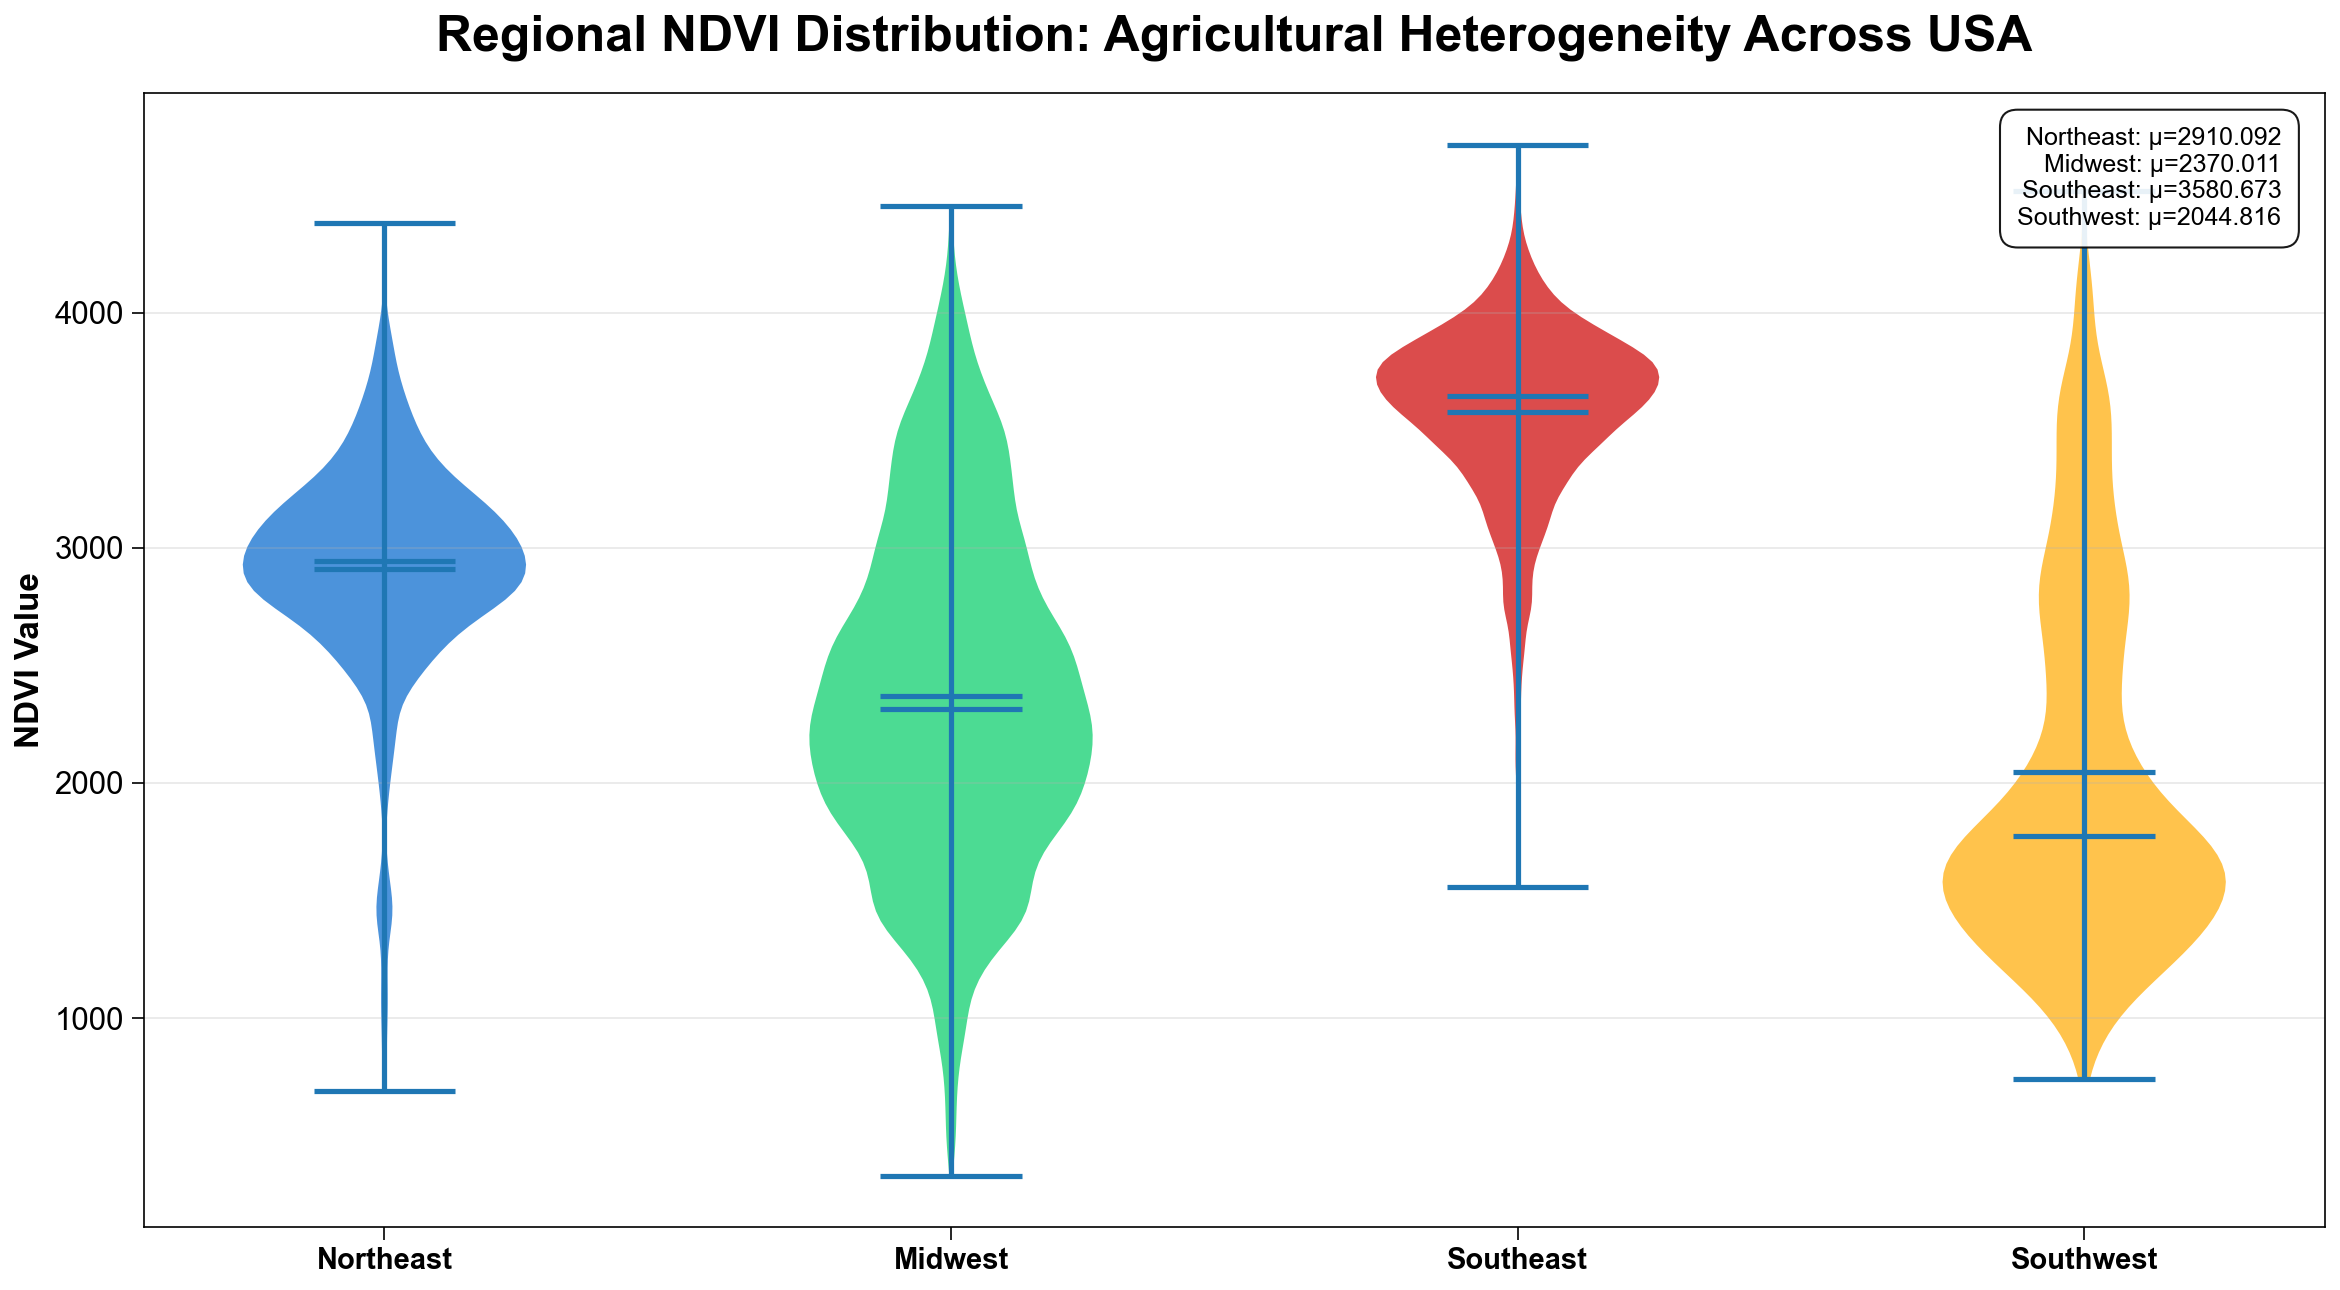

✅ Saved: NDVI_Regional_Comparison.png

✅ All NDVI visualizations complete!


In [72]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings

import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════
# VIBRANT NDVI ANIMATION: USA Vegetation Dynamics (2000-2024)
# ════════════════════════════════════════════════════════════

# 1. PATHS & DATA LOADING
print("Loading spatial and temporal data...")
COUNTY_SHP = Path("/Users/faizahmad/Desktop/grok_live/data/cb_2018_us_county_500k/cb_2018_us_county_500k.shp")
STATE_SHP = Path("/Users/faizahmad/Desktop/grok_live/data/cb_2018_us_state_500k/cb_2018_us_state_500k.shp")
DATA_PATH = Path("/Users/faizahmad/Desktop/multimodal/master csv/ROBUST_ML_DATASET_v1_first_run.csv")

# Load geography
counties = gpd.read_file(COUNTY_SHP)
counties['fips'] = counties['GEOID'].astype(str).str.zfill(5)
states = gpd.read_file(STATE_SHP)

# Filter CONUS
non_conus_fips = ['02', '15', '60', '66', '69', '72', '78']
counties = counties[~counties['STATEFP'].isin(non_conus_fips)]
states = states[~states['STATEFP'].isin(non_conus_fips)]

# Load data
df = pd.read_csv(DATA_PATH, low_memory=False)

# 2. IDENTIFY BEST NDVI COLUMN
print("\nSearching for NDVI columns...")
ndvi_candidates = [
    'NDVI_mean_modis_ndvi',  # MODIS (Preferred: Full 25-year coverage)
    'NDVI_mean_landsat',      # Landsat
    'NDVI_mean_s2',           # Sentinel-2
    'NDVI_EVI_mean',          # Composite
    'NDVI_stdDev_modis_ndvi'
]

ndvi_col = None
for col in ndvi_candidates:
    if col in df.columns:
        ndvi_col = col
        print(f"✅ Using: {ndvi_col}")
        break

if not ndvi_col:
    print("❌ No NDVI column found. Available columns:", [c for c in df.columns if 'NDVI' in c][:5])
    ndvi_col = next((c for c in df.columns if 'NDVI' in c), None)

# Ensure we have FIPS and year
df['fips'] = df['GEOID'].astype(str).str.zfill(5) if 'GEOID' in df.columns else df['fips'].astype(str).str.zfill(5)
df = df[['fips', 'year', ndvi_col]].dropna()
df = df[(df['year'] >= 2000) & (df['year'] <= 2024)]

print(f"Data shape: {df.shape}")
print(f"Year range: {df['year'].min()} to {df['year'].max()}")

# 3. CREATE MULTI-YEAR VISUALIZATION (4-Panel Snapshots)
def plot_ndvi_timeline():
    """Creates 4 snapshots: 2000, 2008, 2015, 2019"""
    
    # Target years
    years_to_plot = [2000, 2008, 2015, 2019]
    
    # Setup figure (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(24, 18))
    axes = axes.flatten()
    
    # Global color scale for consistency
    vmin = df[ndvi_col].min()
    vmax = df[ndvi_col].max()
    
    for idx, year in enumerate(years_to_plot):
        ax = axes[idx]
        
        # Filter data for this year
        year_data = df[df['year'] == year][['fips', ndvi_col]].drop_duplicates()
        
        # Merge with geography
        merged = counties.merge(year_data.rename(columns={ndvi_col: 'ndvi_value'}), 
                               on='fips', how='left')
        
        # Plot with vibrant colormap
        # 'RdYlGn' (Red-Yellow-Green): Perfect for vegetation!
        # Red = Stressed/Brown, Yellow = Transition, Green = Healthy
        merged.plot(column='ndvi_value', 
                   cmap='RdYlGn', 
                   ax=ax, 
                   vmin=vmin, 
                   vmax=vmax,
                   missing_kwds={'color': '#f0f0f0'},
                   edgecolor='none',
                   zorder=1)
        
        # Add state boundaries
        states.geometry.boundary.plot(ax=ax, 
                                     color='#222222', 
                                     linewidth=0.8, 
                                     alpha=0.7,
                                     zorder=2)
        
        # Styling
        ax.set_xlim([-126, -66])
        ax.set_ylim([24, 50])
        ax.axis('off')
        ax.set_title(f'NDVI: {year}', fontsize=22, fontweight='bold', pad=15)
        
        # Add statistics box
        year_stats = df[df['year'] == year][ndvi_col].describe()
        stats_text = (
            f"Mean: {year_stats['mean']:.3f}\n"
            f"Median: {year_stats['50%']:.3f}\n"
            f"Std: {year_stats['std']:.3f}\n"
            f"Counties: {len(year_data):,}"
        )
        props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='gray')
        ax.text(0.02, 0.08, stats_text, transform=ax.transAxes, fontsize=12,
               verticalalignment='bottom', bbox=props)
    
    # Global colorbar
    sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('NDVI Value (Vegetation Health)', fontsize=16, fontweight='bold', labelpad=20)
    
    # Main title
    plt.suptitle(
        f'USA Vegetation Dynamics: 25-Year NDVI Evolution (2000-2024)\nData Source: {ndvi_col.split("_")[0]} Satellite Series',
        fontsize=28, fontweight='bold', y=0.98
    )
    
    # Legend explanation
    fig.text(0.5, 0.01, 
             '🔴 Red = Stressed Vegetation | 🟡 Yellow = Moderate | 🟢 Green = Healthy Vegetation | ⚪ Gray = Missing Data',
             ha='center', fontsize=14, style='italic', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout(rect=[0, 0.03, 0.91, 0.97])
    plt.savefig('NDVI_Timeline_4Panel_Vibrant.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: NDVI_Timeline_4Panel_Vibrant.png")

# 4. ANIMATED HEATMAP (Line Chart of Mean NDVI Over Time)
def plot_ndvi_trend():
    """Time series showing national average NDVI trajectory"""
    
    # Aggregate by year
    yearly_ndvi = df.groupby('year')[ndvi_col].agg(['mean', 'std', 'min', 'max']).reset_index()
    
    fig, ax = plt.subplots(figsize=(16, 9))
    
    # Main line
    ax.plot(yearly_ndvi['year'], yearly_ndvi['mean'], 
           color='#00BB44', marker='o', markersize=8, linewidth=4, label='Mean NDVI', zorder=3)
    
    # Confidence band (std dev)
    ax.fill_between(yearly_ndvi['year'],
                   yearly_ndvi['mean'] - yearly_ndvi['std'],
                   yearly_ndvi['mean'] + yearly_ndvi['std'],
                   color='#00BB44', alpha=0.15, label='±1 Std Dev', zorder=1)
    
    # Min/Max envelope
    ax.fill_between(yearly_ndvi['year'],
                   yearly_ndvi['min'],
                   yearly_ndvi['max'],
                   color='#FF6600', alpha=0.05, label='Min-Max Range', zorder=1)
    
    # Styling
    ax.set_xlabel('Year', fontweight='bold', fontsize=16)
    ax.set_ylabel('NDVI (Vegetation Index)', fontweight='bold', fontsize=16)
    ax.set_title('National NDVI Trend: 25-Year Agricultural & Forest Productivity',
                fontsize=24, fontweight='bold', pad=20)
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=14, loc='best', framealpha=0.95)
    
    # Trend annotation
    slope = (yearly_ndvi['mean'].iloc[-1] - yearly_ndvi['mean'].iloc[0]) / len(yearly_ndvi)
    trend_text = f"Trend: {slope:+.4f} NDVI/year\n"
    if slope > 0:
        trend_text += "🟢 Greening (Positive Trend)"
    else:
        trend_text += "🔴 Browning (Negative Trend)"
    
    props = dict(boxstyle='round,pad=0.7', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=2)
    ax.text(0.02, 0.97, trend_text, transform=ax.transAxes, fontsize=14, fontweight='bold',
           verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.savefig('NDVI_National_Trend_TimeSeries.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: NDVI_National_Trend_TimeSeries.png")

# 5. REGIONAL COMPARISON (North vs South, East vs West)
def plot_ndvi_regional():
    """Boxplot comparing NDVI across 4 regions"""
    
    # Define regions by state code
    df['region'] = 'Other'
    
    # Northeast
    northeast_states = ['09', '10', '23', '25', '33', '34', '36', '42', '44', '50']
    # Southeast
    southeast_states = ['01', '12', '13', '24', '37', '45', '47', '51', '54']
    # Midwest
    midwest_states = ['17', '18', '19', '20', '26', '27', '29', '31', '38', '39', '55', '56']
    # Southwest
    southwest_states = ['04', '06', '08', '16', '30', '32', '35', '40', '41', '49']
    
    df.loc[df['fips'].str[:2].isin(northeast_states), 'region'] = 'Northeast'
    df.loc[df['fips'].str[:2].isin(southeast_states), 'region'] = 'Southeast'
    df.loc[df['fips'].str[:2].isin(midwest_states), 'region'] = 'Midwest'
    df.loc[df['fips'].str[:2].isin(southwest_states), 'region'] = 'Southwest'
    
    fig, ax = plt.subplots(figsize=(16, 9))
    
    # Violin plot (better for distributions)
    regions = ['Northeast', 'Midwest', 'Southeast', 'Southwest']
    region_colors = ['#0066CC', '#00CC66', '#CC0000', '#FFAA00']
    
    data_to_plot = [df[df['region'] == r][ndvi_col].dropna().values for r in regions]
    
    parts = ax.violinplot(data_to_plot, positions=range(len(regions)), showmeans=True, showmedians=True)
    
    # Color the violins
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(region_colors[i])
        pc.set_alpha(0.7)
    
    ax.set_xticks(range(len(regions)))
    ax.set_xticklabels(regions, fontsize=14, fontweight='bold')
    ax.set_ylabel('NDVI Value', fontweight='bold', fontsize=16)
    ax.set_title('Regional NDVI Distribution: Agricultural Heterogeneity Across USA',
                fontsize=24, fontweight='bold', pad=20)
    
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add legend with stats
    stats_lines = []
    for i, region in enumerate(regions):
        region_data = df[df['region'] == region][ndvi_col].dropna()
        mean_val = region_data.mean()
        stats_lines.append(f"{region}: μ={mean_val:.3f}")
    
    props = dict(boxstyle='round,pad=0.7', facecolor='white', alpha=0.9)
    ax.text(0.98, 0.97, '\n'.join(stats_lines), transform=ax.transAxes, fontsize=12,
           verticalalignment='top', horizontalalignment='right', bbox=props)
    
    plt.tight_layout()
    plt.savefig('NDVI_Regional_Comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: NDVI_Regional_Comparison.png")

# ════════════════════════════════════════════════════════════
# EXECUTE ALL VISUALIZATIONS
# ════════════════════════════════════════════════════════════

print("\n🎨 Generating NDVI Visualizations...\n")

plot_ndvi_timeline()
print()
plot_ndvi_trend()
print()
plot_ndvi_regional()

print("\n✅ All NDVI visualizations complete!")

✅ Saved: /Users/faizahmad/Desktop/multimodal/master csv/plotting/Evolution_6Maps_2000_2019.png


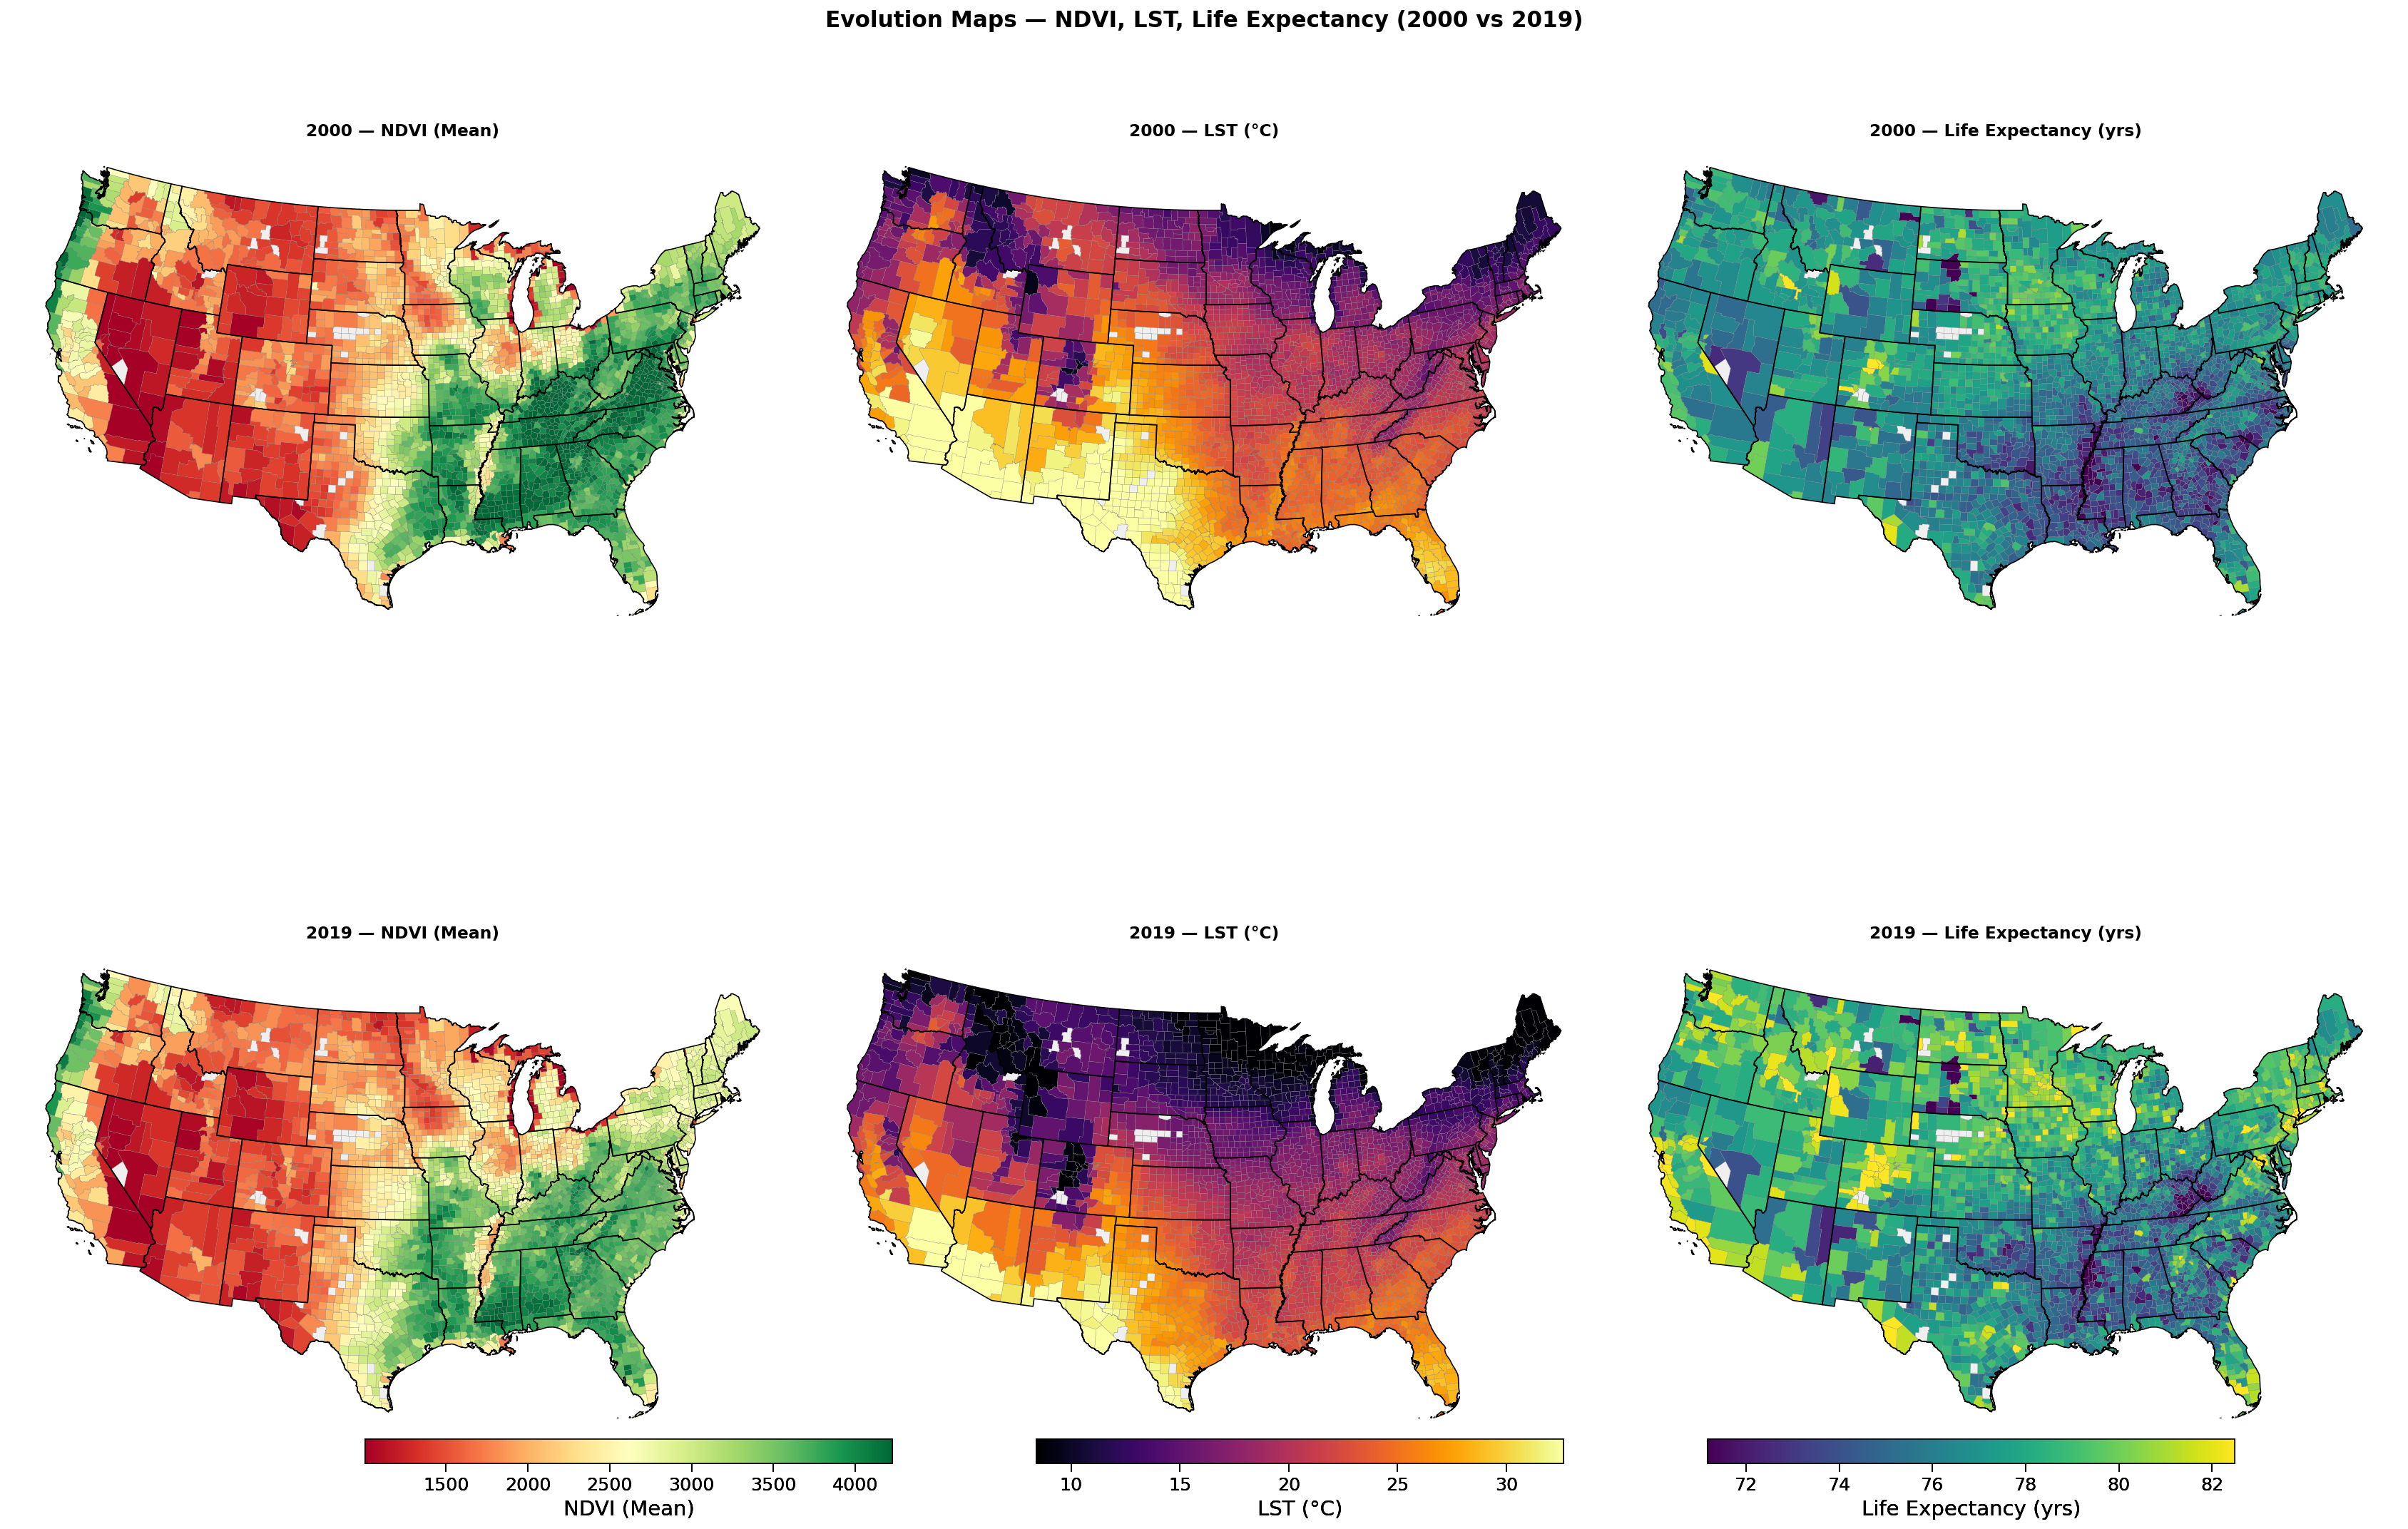

In [125]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import os

# New cell (index 27) — Generate 6 maps (NDVI, LST, LifeExp) for two years (2000 & 2019)
# Layout: 2 rows (years) x 3 cols (NDVI, LST, Life Expectancy)

import matplotlib.pyplot as plt

# --- 1. Config / Paths (uses previous notebook paths when available) ---
BASE_PATH = Path('/Users/faizahmad/Desktop/multimodal/master csv/')
CANDIDATE_MASTER_PATHS = [
    Path(BASE_PATH) / 'master_agricultural_dataset.csv',
    Path('final_ml_ready_agriculture_LE_v2.csv'),
    Path('FullHouse_Final_ML_Ready.csv'),
    Path('efficient_ml_ready_agriculture_LE.csv'),
    Path('merged_agriculture_life_expectancy.csv')
]

MASTER_PATH = next((p for p in CANDIDATE_MASTER_PATHS if p.exists()), None)
if MASTER_PATH is None:
    raise FileNotFoundError("Master dataset not found. Place master_agricultural_dataset.csv or one of the fallback files in working dir or the DRIVE path.")

# county/state shapefiles (from earlier cells)
COUNTY_SHP = Path("/Users/faizahmad/Desktop/grok_live/data/cb_2018_us_county_500k/cb_2018_us_county_500k.shp")
STATE_SHP  = Path("/Users/faizahmad/Desktop/grok_live/data/cb_2018_us_state_500k/cb_2018_us_state_500k.shp")
# If those local shapefiles don't exist, try to use 'counties' / 'states' already in memory
use_memory_shapes = False
try:
    counties  # if exists in notebook
    states
    use_memory_shapes = True
except NameError:
    use_memory_shapes = False

# --- 2. Load data ---
master = pd.read_csv(MASTER_PATH, low_memory=False)
# Normalize fips/GEOID
if 'fips' not in master.columns:
    if 'GEOID' in master.columns:
        master['fips'] = master['GEOID'].astype(str).str.zfill(5)
    elif 'FIPS' in master.columns:
        master['fips'] = master['FIPS'].astype(str).str.zfill(5)
    else:
        raise KeyError("No 'fips' or 'GEOID' column found in master dataset.")

# --- 3. Column discovery (robust) ---
ndvi_col = next((c for c in master.columns if 'NDVI' in c and 'mean' in c.lower()), None)
lst_col  = next((c for c in master.columns if 'LST' in c or 'LST_Day' in c or 'LST_Night' in c), None)
le_col   = next((c for c in master.columns if 'Life Expectancy' in c or 'MeanLifeExpectency' in c or 'MeanLifeExpectancy' in c), None)

if ndvi_col is None:
    ndvi_col = 'NDVI_EVI_mean'  # fallback to variable user provided if present
if lst_col is None:
    lst_col = 'LST_Night_1km_mean'  # fallback
if le_col is None:
    # try common names used in notebook
    for name in ['Life Expectancy (Years)', 'MeanLifeExpectency', 'MeanLifeExpectency_x', 'MeanLifeExpectency_y']:
        if name in master.columns:
            le_col = name
            break

# Validate columns
missing = [name for name in (ndvi_col, lst_col, le_col) if name not in master.columns]
if missing:
    raise KeyError(f"Required columns missing in master dataset: {missing}")

# --- 4. Years and variables to map ---
years = [2000, 2019]  # 6 maps -> 2 years x 3 variables
vars_info = [
    (ndvi_col, "NDVI (Mean)", "RdYlGn"),
    (lst_col,  "LST (°C)",    "inferno"),
    (le_col,   "Life Expectancy (yrs)", "viridis")
]

# Compute global vmin/vmax per variable for consistent color scales
vmins, vmaxs = {}, {}
for col, title, cmap in vars_info:
    vals = master[[col, 'fips', 'year']].dropna()[col]
    if vals.empty:
        vmins[col], vmaxs[col] = 0.0, 1.0
    else:
        vmins[col], vmaxs[col] = float(vals.quantile(0.01)), float(vals.quantile(0.99))

# --- 5. Load county geometries ---
if use_memory_shapes:
    geo_counties = counties.copy()
    geo_states = states.copy()
else:
    if not COUNTY_SHP.exists() or not STATE_SHP.exists():
        raise FileNotFoundError("County/State shapefiles not found at given local paths.")
    geo_counties = gpd.read_file(COUNTY_SHP)
    geo_states = gpd.read_file(STATE_SHP)

# Ensure GEOID/fips column on shapes
if 'fips' not in geo_counties.columns:
    if 'GEOID' in geo_counties.columns:
        geo_counties['fips'] = geo_counties['GEOID'].astype(str).str.zfill(5)
    else:
        # try STATEFP + COUNTYFP
        if {'STATEFP', 'COUNTYFP'}.issubset(geo_counties.columns):
            geo_counties['fips'] = geo_counties['STATEFP'].astype(str).str.zfill(2) + geo_counties['COUNTYFP'].astype(str).str.zfill(3)
        else:
            raise KeyError("County shapefile missing GEOID/STATEFP+COUNTYFP to build fips.")
# Clip to CONUS bounding box for nicer visuals
geo_counties = gpd.read_file(COUNTY_SHP).to_crs(epsg=5070)
geo_states   = gpd.read_file(STATE_SHP).to_crs(5070)

geo_counties['fips'] = geo_counties['GEOID'].astype(str).str.zfill(5)
# geo_states = geo_states[~geo_states.STATEFP.isin(['02','15','72'])]  # exclude AK, HI, PR
# Exclude non-CONUS states/territories (AK, HI, PR, VI, GU, AS, MP)
non_conus_fips = ['02', '15', '72', '66', '69', '78', '60']
geo_states   = geo_states[~geo_states['STATEFP'].isin(non_conus_fips)].copy()
geo_counties = geo_counties[geo_counties['STATEFP'].isin(geo_states['STATEFP'])].copy()

# --- 6. Build figure ---
fig, axes = plt.subplots(nrows=len(years), ncols=len(vars_info), figsize=(24, 16), constrained_layout=True)

for i, year in enumerate(years):
    df_year = master[master['year'] == year].copy()

    # Ensure 'fips' is string and zero-padded in the dataframe to match shapefile values
    if df_year['fips'].dtype != object:
        df_year['fips'] = df_year['fips'].astype(str)
    df_year['fips'] = df_year['fips'].str.zfill(5)

    # aggregate by fips (mean) to ensure single value per county
    agg = df_year.groupby('fips')[[v[0] for v in vars_info]].mean().reset_index()

    # Make sure geo_counties has fips as string (zero-padded) as well to avoid dtype mismatch
    if geo_counties['fips'].dtype != object:
        geo_counties['fips'] = geo_counties['fips'].astype(str)
    geo_counties['fips'] = geo_counties['fips'].str.zfill(5)

    merged = geo_counties.merge(agg, on='fips', how='left')

    for j, (col, title, cmap) in enumerate(vars_info):
        ax = axes[i, j] if axes.ndim > 1 else axes[max(i, j)]
        vmin, vmax = vmins[col], vmaxs[col]

        merged.plot(column=col, cmap=cmap, ax=ax, vmin=vmin, vmax=vmax,
                    missing_kwds={'color': '#efefef'}, linewidth=0.15, edgecolor='gray')

        # state boundaries
        geo_states.geometry.boundary.plot(ax=ax, color='black', linewidth=0.8, zorder=3)

        ax.set_title(f"{year} — {title}", fontsize=12, fontweight='bold')
        ax.set_axis_off()

        # colorbar per column (only add once per column for clarity)
        # After the inner loop:
        if i == len(years)-1:  # only bottom row
            for j, (col, title, cmap) in enumerate(vars_info):
                sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmins[col], vmaxs[col]), cmap=cmap)
                cax = fig.add_axes([0.15 + j*0.28, 0.08, 0.22, 0.015])  # horizontal
                fig.colorbar(sm, cax=cax, orientation='horizontal', label=title)

# Overall title and save
plt.suptitle("Evolution Maps — NDVI, LST, Life Expectancy (2000 vs 2019)", fontsize=16, fontweight='bold', y=0.99)
out_path = Path(BASE_PATH) / 'plotting' / 'Evolution_6Maps_2000_2019.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {out_path}")

plt.show()

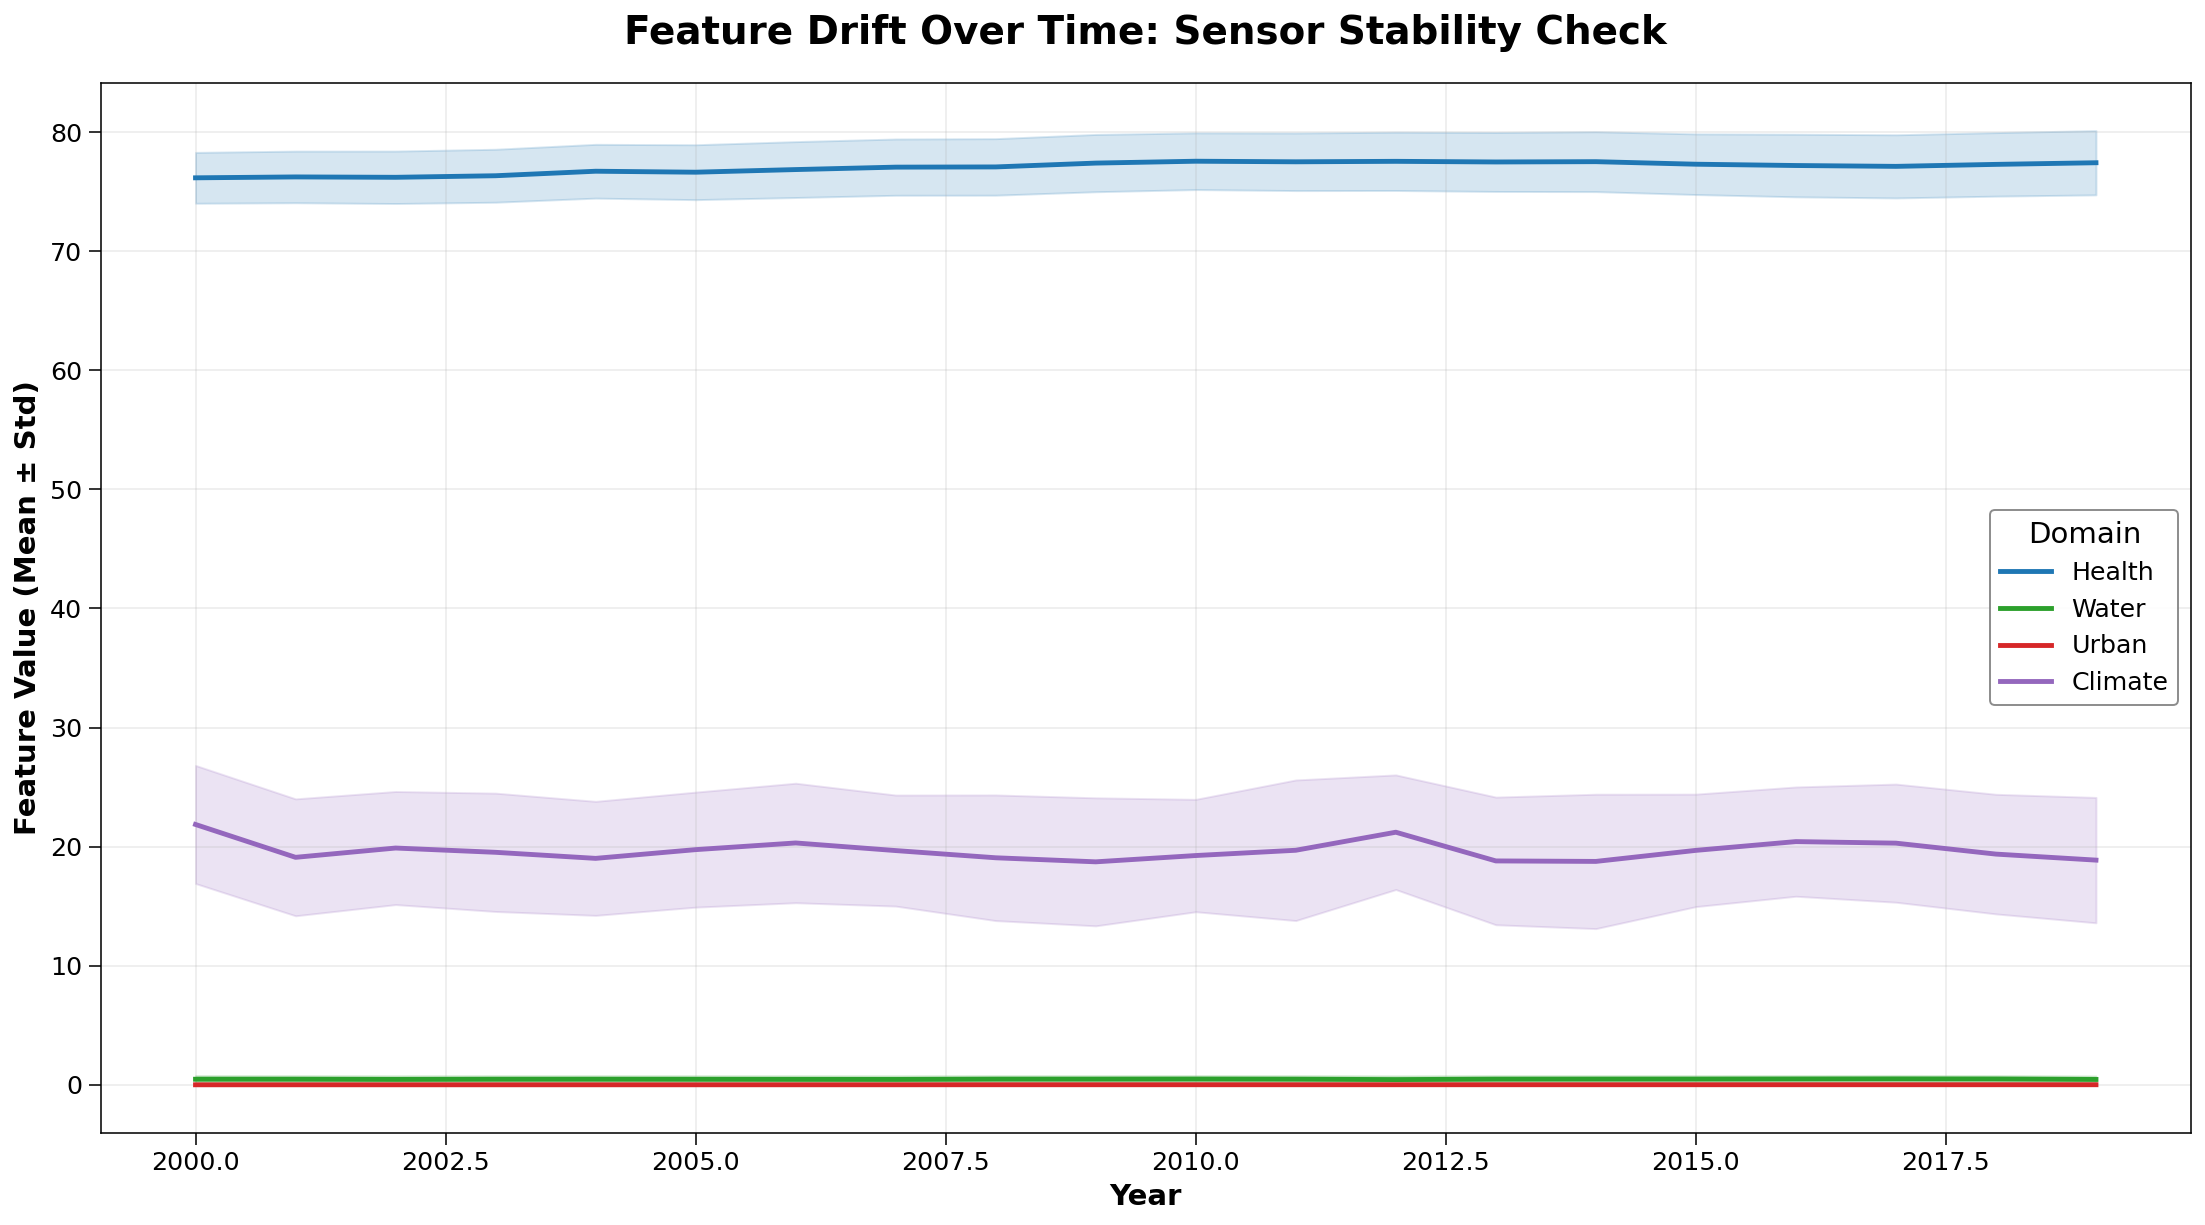

In [129]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# --- Load Data ---
csv_path = '/Users/faizahmad/Desktop/multimodal/master csv/ROBUST_ML_DATASET_v1_first_run.csv'
df = pd.read_csv(csv_path, low_memory=False)

# --- Robust Column Search ---
feature_map = {
    'Health': 'MeanLifeExpectency',
    'Vegetation': 'NDVI_mean_s2',
    'Water': 'JRC_Water_JRC_Permanent_pct',
    'Urban': 'USDA_Cropland_USDA_Dev_High_pct',
    'Climate': 'LST_Day_1km_mean',
    'SAR': 'VV_mean_s1'
}

# Fallbacks if column not found
for k, v in feature_map.items():
    if v not in df.columns:
        # Try partial match
        alt = next((c for c in df.columns if k.lower() in c.lower() or v.lower() in c.lower()), None)
        if alt:
            feature_map[k] = alt

# --- Plotting ---
years = sorted(df['year'].dropna().unique())
fig, ax = plt.subplots(figsize=(16, 9))

colors = plt.cm.tab10.colors
for i, (domain, col) in enumerate(feature_map.items()):
    if col not in df.columns:
        continue
    stats = df.groupby('year')[col].agg(['mean', 'std']).dropna()
    ax.plot(stats.index, stats['mean'], label=f"{domain}", color=colors[i])
    ax.fill_between(stats.index, stats['mean'] - stats['std'], stats['mean'] + stats['std'],
                    color=colors[i], alpha=0.18)

ax.set_xlabel('Year', fontsize=15, fontweight='bold')
ax.set_ylabel('Feature Value (Mean ± Std)', fontsize=15, fontweight='bold')
ax.set_title('Feature Drift Over Time: Sensor Stability Check', fontsize=20, fontweight='bold', pad=20)
ax.legend(title='Domain', fontsize=13)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('Feature_Drift_Over_Time.png', dpi=300)
plt.show()

In [183]:
df = pd.read_csv('/Users/faizahmad/Desktop/LE Crop data/merged_agriculture_life_expectancy.csv', low_memory=False)

df.columns.to_list()



['location_name',
 'fips',
 'year',
 'MeanLifeExpectency_x',
 'MeanLifeExpectency_y',
 'USDA_mean',
 'USDA_stdDev',
 'USDA_Cropland_USDA_Corn_pct',
 'USDA_Cropland_USDA_Fallow_pct',
 'USDA_Cropland_USDA_Class_88_pct',
 'USDA_Cropland_USDA_Soybeans_pct',
 'USDA_Cropland_USDA_Class_83_pct',
 'USDA_Cropland_USDA_Class_82_pct',
 'USDA_Cropland_USDA_Class_81_pct',
 'USDA_Cropland_USDA_Grassland_pct',
 'USDA_Cropland_USDA_Class_63_pct',
 'USDA_Cropland_USDA_Class_29_pct',
 'USDA_Cropland_USDA_Class_25_pct',
 'USDA_Cropland_USDA_Sunflower_pct',
 'USDA_Cropland_USDA_Alfalfa_pct',
 'USDA_Cropland_USDA_Spring Wheat_pct',
 'USDA_Cropland_USDA_Barley_pct',
 'USDA_Cropland_USDA_Class_22_pct',
 'USDA_Cropland_USDA_Oats_pct',
 'USDA_Cropland_USDA_Other Crops_pct',
 'USDA_Cropland_USDA_Class_42_pct',
 'USDA_Cropland_USDA_Winter Wheat_pct',
 'USDA_Cropland_USDA_Class_47_pct',
 'USDA_Cropland_USDA_Class_87_pct',
 'USDA_Cropland_USDA_Class_53_pct',
 'USDA_Cropland_USDA_Cotton_pct',
 'USDA_Cropland_USDA_C

In [188]:
unique_columns = set(df.columns)
unique_columns_ml = set(df_ml.columns)
common_columns = unique_columns.intersection(unique_columns_ml)
print(f"Common columns between the two datasets: {common_columns}")

Common columns between the two datasets: {'S2_EVI_stdDev', 'S2_NDVI_p90', 'USDA_Cropland_USDA_Class_53_pct', 'S2_NDWI_p50', 'S2_B3_p90', 'USDA_Cropland_USDA_Class_52_pct', 'S1_VV_corr_p25', 'USDA_mean', 'USDA_Cropland_USDA_Class_204_pct', 'S2_NDVI_p25', 'Landsat_NDWI_stdDev', 'S2_NDWI_stdDev', 'USDA_Cropland_USDA_Class_217_pct', 'DEM_stdDev', 'LST_Day_1km_p25', 'Landsat_SAVI_p25', 'USDA_Cropland_USDA_Class_83_pct', 'S2_B11_p10', 'USDA_Cropland_USDA_Class_48_pct', 'Landsat_EVI_p25', 'S2_B3_p25', 'USDA_Cropland_USDA_Class_225_pct', 'LST_Day_1km_p10', 'S1_VV_p10', 'USDA_Cropland_USDA_Class_207_pct', 'S1_VH_mean', 'S2_NDMI_p90', 'USDA_Cropland_USDA_Class_215_pct', 'USDA_Cropland_USDA_Class_234_pct', 'DEM_p10', 'USDA_Cropland_USDA_Class_229_pct', 'Landsat_NDVI_p75', 'Landsat_SR_B6_stdDev', 'S2_B11_p50', 'USDA_Cropland_USDA_Class_208_pct', 'USDA_Cropland_USDA_Class_50_pct', 'USDA_Cropland_USDA_Class_27_pct', 'LST_Day_1km_p75', 'Landsat_BSI_stdDev', 'USDA_Cropland_USDA_Spring Wheat_pct', 'Lan

Note: using global `year` variable as color (single value).
Saved: /Users/faizahmad/Desktop/multimodal/sanity_check/plots/NDVI_vs_LST_Physical_Plausibility.png


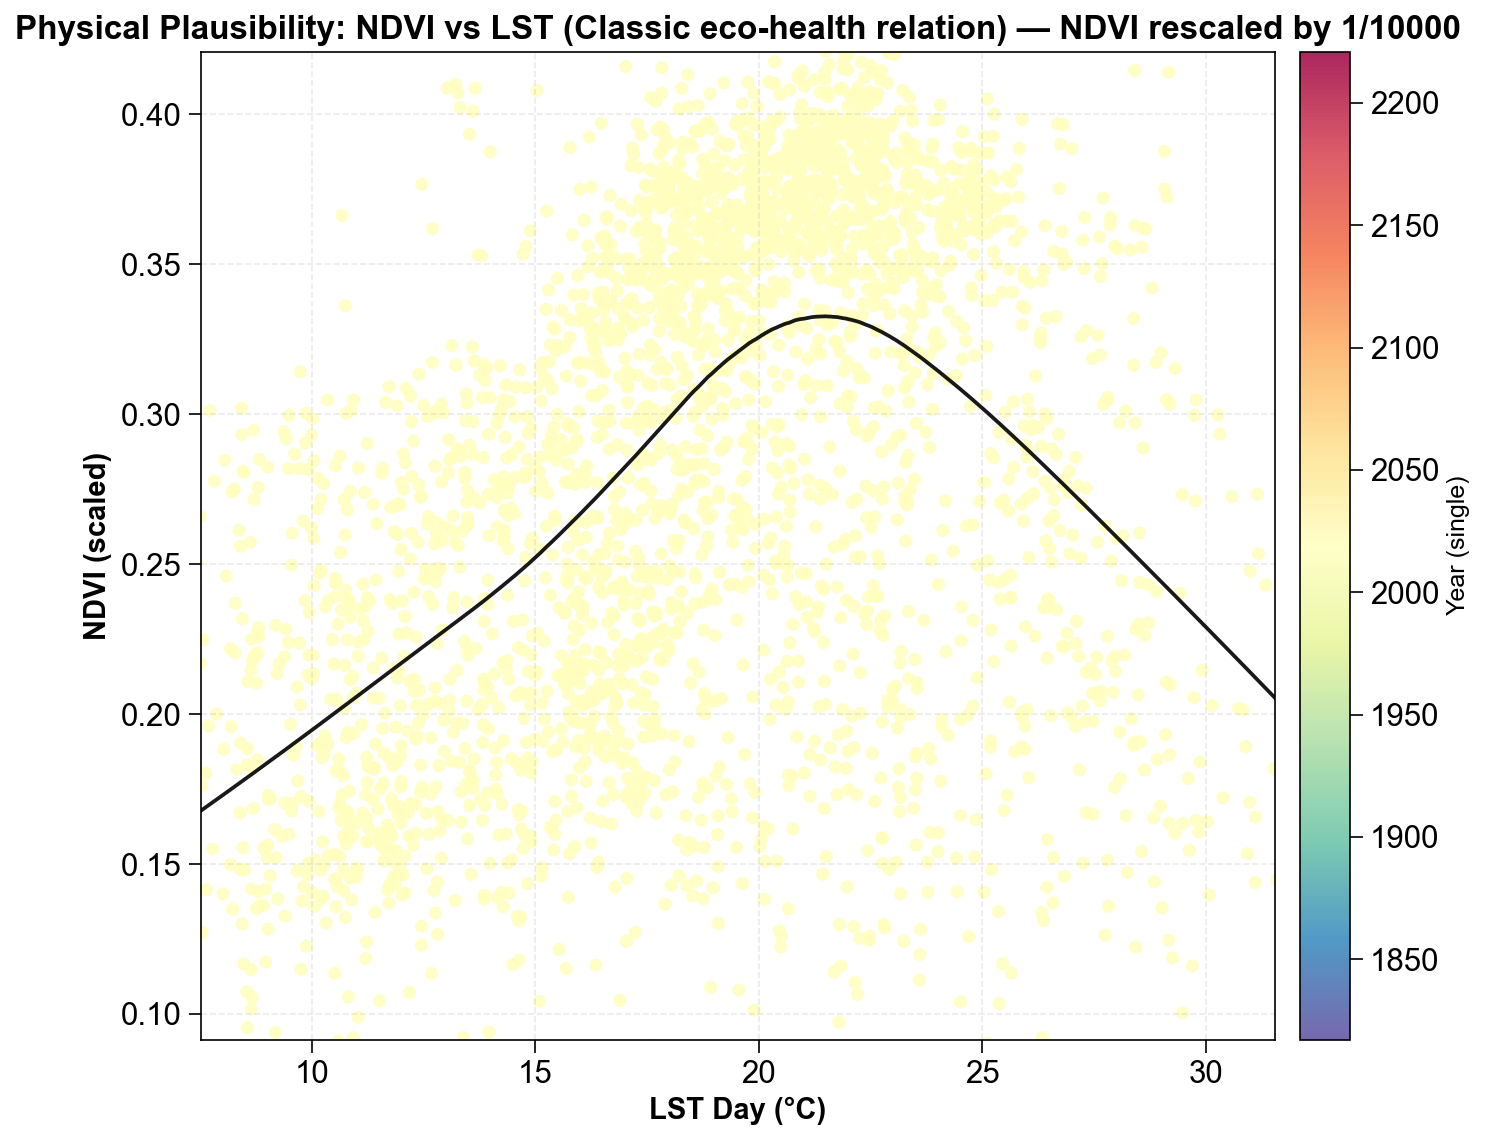

In [86]:
import seaborn as sns

# Scatter / physics check: NDVI vs LST colored by year (falls back sensibly if year missing)
# Uses existing `merged` GeoDataFrame in notebook.

# Config
x_col = 'LST_Day_1km_mean'
y_col = 'NDVI_EVI_mean'   # your NDVI candidate in `merged`
out_dir = globals().get('PLOT_DIR', None) or './plotting'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'NDVI_vs_LST_Physical_Plausibility.png')

# Validate columns
if x_col not in merged.columns or y_col not in merged.columns:
    raise KeyError(f"Required columns not found in `merged`: need '{x_col}' and '{y_col}'")

# Prepare data
plot_df = merged[[x_col, y_col]].copy()

# If NDVI is in integer large scale (looks like 0-10000 or 0-1000), rescale to 0-1 for interpretability
y_max = plot_df[y_col].max(skipna=True)
if y_max is None:
    raise ValueError("NDVI column contains no valid values.")
scale_note = ""
if y_max > 2.5:
    # Try typical GEE scale factors
    if y_max > 2000:
        plot_df['NDVI_scaled'] = plot_df[y_col] / 10000.0
        scale_note = "NDVI rescaled by 1/10000"
    elif y_max > 2.5 and y_max <= 2000:
        plot_df['NDVI_scaled'] = plot_df[y_col] / 1000.0
        scale_note = "NDVI rescaled by 1/1000"
else:
    plot_df['NDVI_scaled'] = plot_df[y_col]

# Determine color column (prefer 'year')
if 'year' in merged.columns:
    plot_df['color_by'] = merged['year']
    c_label = 'Year'
elif 'year' in globals() and isinstance(globals()['year'], (int, float)):
    plot_df['color_by'] = globals()['year']  # single year in session
    c_label = 'Year (single)'
    print("Note: using global `year` variable as color (single value).")
else:
    # fallback: color by life expectancy proxy
    fallback_col = 'MeanLifeExpectency_x' if 'MeanLifeExpectency_x' in merged.columns else None
    if fallback_col:
        plot_df['color_by'] = merged[fallback_col]
        c_label = 'Life Expectancy (proxy)'
        print("Warning: 'year' not found in `merged`. Coloring by Life Expectancy proxy.")
    else:
        plot_df['color_by'] = np.arange(len(plot_df))  # ordinal
        c_label = 'Index'
        print("Warning: neither 'year' nor life-expectancy proxy found. Coloring by index.")

# Drop rows with missing values in the required columns
plot_df = plot_df.dropna(subset=[x_col, 'NDVI_scaled', 'color_by'])
if plot_df.empty:
    raise ValueError("No valid rows to plot after dropping NaNs.")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    plot_df[x_col],
    plot_df['NDVI_scaled'],
    c=plot_df['color_by'],
    cmap='Spectral_r',
    s=40,
    alpha=0.85,
    edgecolors='none'
)

# Add lowess-like trend / robust regression (seaborn)
try:
    sns.regplot(x=plot_df[x_col], y=plot_df['NDVI_scaled'], scatter=False,
                lowess=True, ax=ax, line_kws={'color': 'k', 'linewidth': 1.8, 'alpha': 0.9})
except Exception:
    # fallback: simple linear fit
    coef = np.polyfit(plot_df[x_col], plot_df['NDVI_scaled'], 1)
    xs = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 100)
    ax.plot(xs, np.polyval(coef, xs), color='k', linewidth=1.5, alpha=0.9)

# Axis labels & title
ax.set_xlabel('LST Day (°C)', fontsize=14, fontweight='bold')
ax.set_ylabel('NDVI (scaled)', fontsize=14, fontweight='bold')
title = "Physical Plausibility: NDVI vs LST (Classic eco-health relation)"
if scale_note:
    title += f" — {scale_note}"
ax.set_title(title, fontsize=16, fontweight='bold')

# Colorbar
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(c_label, fontsize=12)

# Styling
ax.grid(alpha=0.25, linestyle='--')
ax.set_xlim(plot_df[x_col].quantile(0.01), plot_df[x_col].quantile(0.99))
ax.set_ylim(plot_df['NDVI_scaled'].quantile(0.005), plot_df['NDVI_scaled'].quantile(0.995))

# Save & show
plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()